# SeedGerm-VIG minimal reproduction — G7 wheat germination time series (Colab, T4 GPU)

Reproduces the minimal example of **"SeedGerm-VIG: an open and comprehensive pipeline to
quantify seed vigor in wheat and other cereal crops using deep learning-powered dynamic
phenotypic analysis"** (Dai, Wen & Zhou, *GigaScience* 2025;14:giaf129,
[doi:10.1093/gigascience/giaf129](https://doi.org/10.1093/gigascience/giaf129), open access via PMC12648739).

**Scope (single-example demonstration, not a full-paper benchmark):** run the authors' released
pipeline on their exemplar **black-paper G7 wheat series** (16 time-lapse images, 5 h interval,
5×5 = 25 seeds): (1) U-Net segmentation masks (overall/seed/seedling), (2) YOLOv8x-Germ
germination-phase detection, (3) temporal phase correction → seed-level and seed-lot phase
time points, and (4) skeleton-based root-tip tracking → radicle growth profiles. Results are
compared against the reference outputs the authors pinned at commit `cd86a6f0c81e`.

**実行内容(日本語):** 論文著者公開の SeedGerm-VIG パイプラインを、公開されている小麦 G7
発芽タイムラプス例(16 枚・5 時間間隔・25 粒)で実行します。U-Net によるセグメンテーション、
YOLOv8x-Germ による発芽段階検出、時間方向のフェーズ補正(种子レベル/ロットレベル)、
根端追跡による幼根プロファイルを再現し、著者公開の参照出力と比較します。

**Sources / licenses:** author code & notebooks: `The-Zhou-Lab/SeedGerm-VIG` tag **v1.12**
(commit `cd86a6f0c81e`, MIT); example images & reference outputs: same pinned commit
(image series CC0, BioImage Archive S-BIAD1852); model weights: release asset
`DL_models_for_wheat.zip` (MIT). Author notebooks were copied nearly verbatim; small,
documented adaptations are marked `# ADAPTATION` in code cells.


## Runtime selection — please use a **T4 GPU** runtime

`ランタイム → ランタイムのタイプを変更 → T4 GPU` を選択してから「すべてのセルを実行」してください。
The authors state the pipeline was **only tested with NVIDIA GPUs** (README, pinned commit). The DL
parts (3×U-Net + YOLOv8x) need the GPU; the skimage/scipy morphology runs on CPU either way.

**Expectations (estimates, verified values are printed at the end):** ~0.4 GB downloads
(283 MB weights + ~74 MB images + small CSVs); total wall time **~15–40 min** (DL inference is
seconds per frame on T4; the skimage/scipy root-tip tracking dominates and runs on CPU either
way). A T4 GPU is required; on CPU the DL inference is not paper-faithful.


In [ ]:
# Environment report, TF memory growth, and stage timer
import time
T0 = time.time()
STAGES = []
def stage(name):
    STAGES.append((name, time.time() - T0))
    print(f"[stage] {name}: {time.time()-T0:,.0f} s since start")

import subprocess, sys
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                     capture_output=True, text=True).stdout.strip() or "NO GPU VISIBLE")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
# ADAPTATION (required): let TF grow GPU memory instead of grabbing all T4 VRAM,
# so the later PyTorch/ultralytics inference can share the GPU (verified in probe).
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)
print("tensorflow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))
import numpy, scipy, skimage, pandas, cv2
print("numpy", numpy.__version__, "| scipy", scipy.__version__, "| skimage", skimage.__version__,
      "| pandas", pandas.__version__, "| opencv", cv2.__version__)

Tesla T4, 15360 MiB


tensorflow 2.21.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
numpy 2.1.3 | scipy 1.16.3 | skimage 0.25.2 | pandas 2.2.3 | opencv 4.14.0


## Install the remaining dependency (`ultralytics`)

TF, numpy/scipy/skimage/pandas/opencv are preinstalled on Colab; `ultralytics` is not.
`# ADAPTATION`: the authors pinned Python 3.7.12 / TensorFlow 2.2 / PyTorch 1.13.1 /
ultralytics 8.0.145 — a 2020-era stack that cannot run on current Colab. We keep the authors'
*algorithms and weights* unchanged and run them on current Colab frameworks; verified versions
are printed above/below.


In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"],
                   capture_output=True, text=True)
assert r.returncode == 0, r.stderr[-2000:]
import ultralytics
print("ultralytics", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


ultralytics 8.4.174


## Download the pinned wheat DL models (release v1.12 asset, 283 MB) and extract

Weights stay on the Colab VM. Size is checked against the release asset listing
(283,090,451 bytes) before extraction. **Data/weights are never downloaded to the authoring
host** — this notebook is the only execution environment.


In [ ]:
import urllib.request, zipfile, os, hashlib
WEIGHTS_URL = "https://github.com/The-Zhou-Lab/SeedGerm-VIG/releases/download/v1.12/DL_models_for_wheat.zip"
WEIGHTS_SIZE = 283090451
zp = "/content/DL_models_for_wheat.zip"
if not os.path.exists(zp):
    urllib.request.urlretrieve(WEIGHTS_URL, zp)
size = os.path.getsize(zp)
assert size == WEIGHTS_SIZE, f"unexpected archive size {size}"
print("archive OK:", size, "bytes")

os.makedirs("/content/SeedGerm-VIG", exist_ok=True)
with zipfile.ZipFile(zp) as z:
    names = z.namelist()
    print("archive entries:", len(names))
    z.extractall("/content/SeedGerm-VIG/")
stage("weights downloaded+extracted")

archive OK: 283090451 bytes
archive entries: 23


[stage] weights downloaded+extracted: 25 s since start


## Locate the model files and load the three U-Nets

The author Step_1 loads `./models/U-net_wheat_{overall,seed,seedling}_detection/` with
`tf.keras.models.load_model`. `# ADAPTATION`: on current TF we first try the Keras loader
(`compile=False`), and fall back to `tf.saved_model.load` + the serving signature if the
2020-era SavedModel needs it; the predictor below calls whichever handle loaded.


In [ ]:
import glob, tensorflow as tf
MODELS = {}
for key in ["overall", "seed", "seedling"]:
    cand = sorted(glob.glob(f"/content/SeedGerm-VIG/**/U-net_wheat_{key}_detection*", recursive=True))
    assert cand, f"U-net_wheat_{key}_detection not found in archive"
    mp = cand[0]
    try:
        # primary path (verified in the diagnostic probe on TF 2.21): legacy SavedModel
        m = tf.saved_model.load(mp)
        src = "saved_model"
    except Exception as e:
        print(f"[{key}] saved_model load failed ({type(e).__name__}); trying keras")
        m = tf.keras.models.load_model(mp, compile=False)
        src = "keras"
    MODELS[key] = (m, src)
    if src == "saved_model":
        sig = m.signatures.get("serving_default") or list(m.signatures.values())[0]
        print(f"[{key}] <- {mp} via saved_model; input {sig.inputs[0].shape if hasattr(sig.inputs,'__len__') else ''}")
    else:
        print(f"[{key}] <- {mp} via keras")
pt = sorted(glob.glob("/content/SeedGerm-VIG/**/YOLOv8x-Germ.pt", recursive=True))
assert pt, "YOLOv8x-Germ.pt not found in archive"
YOLO_PT = pt[0]
print("YOLO checkpoint:", YOLO_PT)

[overall] <- /content/SeedGerm-VIG/models/U-net_wheat_overall_detection via saved_model; input (None, 512, 512, 3)


[seed] <- /content/SeedGerm-VIG/models/U-net_wheat_seed_detection via saved_model; input (None, 512, 512, 3)


[seedling] <- /content/SeedGerm-VIG/models/U-net_wheat_seedling_detection via saved_model; input (None, 512, 512, 3)
YOLO checkpoint: /content/SeedGerm-VIG/models/YOLOv8x-Germ.pt


## Download the 16 pinned G7 example images and verify every byte

Images are **data** and are fetched here in Colab only. Each file is checked against its Git
blob SHA-1 from the pinned tree (`The-Zhou-Lab/SeedGerm-VIG` @ `cd86a6f0c81e`, path
`example_G7/`), so provenance is byte-exact.


In [ ]:
import urllib.request, hashlib, os
COMMIT = "cd86a6f0c81e1ae0a4e2b9e65fc9a062559601b6"
# small pinned manifest (16 images); reference-output manifests are handled in the verification section
import json
manifest = {
"example_G7/G7_20221026_1637.jpg": {
"size": 4593778,
"sha1": "c3004ee95d5f8779cab9cdb3d519408601932756"
},
"example_G7/G7_20221026_2138.jpg": {
"size": 4622061,
"sha1": "d17dd804a4454ece3a8112a967ddb80c47170494"
},
"example_G7/G7_20221027_0239.jpg": {
"size": 4601306,
"sha1": "383c31b82a669ae4319562f1852589cf8d847b15"
},
"example_G7/G7_20221027_0741.jpg": {
"size": 4620058,
"sha1": "790b348302e6595992744afe6cd25a896bc1b00e"
},
"example_G7/G7_20221027_1242.jpg": {
"size": 4649018,
"sha1": "13430ffe80646e6faddffbb14668df43595ef0a4"
},
"example_G7/G7_20221027_1744.jpg": {
"size": 4618141,
"sha1": "c04d318474d415fc3f625b4683d0ada917ccf1a0"
},
"example_G7/G7_20221027_2245.jpg": {
"size": 4614645,
"sha1": "710894a14fe216fe05cf9f82ebe4a343928ba530"
},
"example_G7/G7_20221028_0347.jpg": {
"size": 4622437,
"sha1": "72fe373019c84d4803d61825360ee036c012134d"
},
"example_G7/G7_20221028_0848.jpg": {
"size": 4630722,
"sha1": "1e4aa6fdb6f5390643a88e21d12b04e1cb46c0e1"
},
"example_G7/G7_20221028_1350.jpg": {
"size": 4658337,
"sha1": "bab4f159e90e9837df5175d4d17638c2c994e319"
},
"example_G7/G7_20221028_1851.jpg": {
"size": 4684632,
"sha1": "60005bb488ebcbe7f60311a39682808403fbbf4b"
},
"example_G7/G7_20221028_2352.jpg": {
"size": 4674857,
"sha1": "618f258c5d4b5688548b1bace8780eeb56b8b17a"
},
"example_G7/G7_20221029_0454.jpg": {
"size": 4718271,
"sha1": "cbad343ff5f86f2fc8fc18204b359f8b4b0d76b9"
},
"example_G7/G7_20221029_0955.jpg": {
"size": 4756877,
"sha1": "6030eb3f51843a3333ef4c6a00b06095633f0965"
},
"example_G7/G7_20221029_1457.jpg": {
"size": 4815868,
"sha1": "7784bebf944f866705ad1281438e9bd8b32b8f75"
},
"example_G7/G7_20221029_2018.jpg": {
"size": 4869774,
"sha1": "94ce41581de1290cf82487549fa47ff6256e570a"
},
"model_predict/G7_overall/G7_20221026_1637.png": {
"size": 14146,
"sha1": "919b6fd82fa35f8b8b4ea05bac2be2ab6f5d5c36"
},
"model_predict/G7_overall/G7_20221026_2138.png": {
"size": 14288,
"sha1": "f6360cadb5046f8ce57c81f30595eb58cc279b06"
},
"model_predict/G7_overall/G7_20221027_0239.png": {
"size": 14317,
"sha1": "b76ec96585cc225137fb773b888c8bc471ee0521"
},
"model_predict/G7_overall/G7_20221027_0741.png": {
"size": 14607,
"sha1": "bd27c6de9057dffd0df0bf45fdbc5b2cff4678fd"
},
"model_predict/G7_overall/G7_20221027_1242.png": {
"size": 14594,
"sha1": "d489a2a6d65e0afc5066ede32d7d0892794ff1ec"
},
"model_predict/G7_overall/G7_20221027_1744.png": {
"size": 14544,
"sha1": "ad7cdc78fd6ad8be7f7378f7bbe55cbb98374a23"
},
"model_predict/G7_overall/G7_20221027_2245.png": {
"size": 14756,
"sha1": "ae6ed2d38ed5c7fbf928966dea218c25294673a1"
},
"model_predict/G7_overall/G7_20221028_0347.png": {
"size": 15076,
"sha1": "fd90eaec55ae41d6a46afc39bc72f6420add5092"
},
"model_predict/G7_overall/G7_20221028_0848.png": {
"size": 15693,
"sha1": "25da275dd364f2668aebf45f29a1c23046f705d8"
},
"model_predict/G7_overall/G7_20221028_1350.png": {
"size": 17272,
"sha1": "d06e1a04425c672652a12f7758593013ef5dff42"
},
"model_predict/G7_overall/G7_20221028_1851.png": {
"size": 19077,
"sha1": "0fcc60ce313d43fa34dc9aa4f1c7c26f4393a508"
},
"model_predict/G7_overall/G7_20221028_2352.png": {
"size": 21662,
"sha1": "18d0d82e315b86f95799a2bd71a721f80f3260e9"
},
"model_predict/G7_overall/G7_20221029_0454.png": {
"size": 25649,
"sha1": "2594a48cfe89f2c3140b4245aac7266b32d8e132"
},
"model_predict/G7_overall/G7_20221029_0955.png": {
"size": 29770,
"sha1": "b5f3913ebf939e573cb366c940bacd792edea593"
},
"model_predict/G7_overall/G7_20221029_1457.png": {
"size": 34933,
"sha1": "2a1f6dfd19154b5599c9200ce8b64340dd96acfd"
},
"model_predict/G7_overall/G7_20221029_2018.png": {
"size": 40485,
"sha1": "a42ba910e9782479bc414b53117b099b3ffd3895"
},
"model_predict/G7_phase/G7_20221026_1637.pkl": {
"size": 4290,
"sha1": "19f731a553d4204b4acd29f92ba6e996b2e32e00"
},
"model_predict/G7_phase/G7_20221026_2138.pkl": {
"size": 4290,
"sha1": "933bb567366aef7383f90b38b979c4ed9365a9da"
},
"model_predict/G7_phase/G7_20221027_0239.pkl": {
"size": 4290,
"sha1": "0cf06c1d3fa3bee83b4b9851798ab309f835e1f8"
},
"model_predict/G7_phase/G7_20221027_0741.pkl": {
"size": 4290,
"sha1": "3bbe42be45cb37b9a5f83b447f0aee410c0397ec"
},
"model_predict/G7_phase/G7_20221027_1242.pkl": {
"size": 4290,
"sha1": "cc54013810e141558b570bfac6835ff0ea6de0d8"
},
"model_predict/G7_phase/G7_20221027_1744.pkl": {
"size": 4290,
"sha1": "16b56a7e6e5e3418a9c2221e477f9ebb6ddc127c"
},
"model_predict/G7_phase/G7_20221027_2245.pkl": {
"size": 4290,
"sha1": "0366bcbd711a787fa47d6c0f9454c85ac241828f"
},
"model_predict/G7_phase/G7_20221028_0347.pkl": {
"size": 4898,
"sha1": "6f18db3842afd4e6968c41cf417c6641fc9c48be"
},
"model_predict/G7_phase/G7_20221028_0848.pkl": {
"size": 4746,
"sha1": "ab357dbced26d00dd68a7b40206991f86e671f8d"
},
"model_predict/G7_phase/G7_20221028_1350.pkl": {
"size": 4594,
"sha1": "2cff4c61aa9fa16984bc25df9ed8372074cfffb6"
},
"model_predict/G7_phase/G7_20221028_1851.pkl": {
"size": 4746,
"sha1": "49b617e420f0dfec4b37313e070f8d67b54e9a97"
},
"model_predict/G7_phase/G7_20221028_2352.pkl": {
"size": 4290,
"sha1": "5334356c99edb338c244f05c9e8e76e0267e7bb2"
},
"model_predict/G7_phase/G7_20221029_0454.pkl": {
"size": 4594,
"sha1": "0d30de5193f04a3107cb167d5ab12d8f922e3afb"
},
"model_predict/G7_phase/G7_20221029_0955.pkl": {
"size": 4594,
"sha1": "9d36cfbb8c522f55d51319b9916eb5103d5bf8e7"
},
"model_predict/G7_phase/G7_20221029_1457.pkl": {
"size": 4898,
"sha1": "0854bef3a97f3c7dc33bb2256ff481c50e70143d"
},
"model_predict/G7_phase/G7_20221029_2018.pkl": {
"size": 4594,
"sha1": "7adc71f0a8a5fce048a1ce3cec807b8949114bf6"
},
"model_predict/G7_seed/G7_20221026_1637.png": {
"size": 13966,
"sha1": "792f525c1d581d569949c9382209429505136d19"
},
"model_predict/G7_seed/G7_20221026_2138.png": {
"size": 14106,
"sha1": "cdeed7af1500d17b8c0e82a3ccb35c736cccc5d4"
},
"model_predict/G7_seed/G7_20221027_0239.png": {
"size": 14200,
"sha1": "08aea3a46b728c5434199ddc6c425ee9cabdd280"
},
"model_predict/G7_seed/G7_20221027_0741.png": {
"size": 14437,
"sha1": "9a28a36aee473ad50a0576f3ae3bba73ab0f09e4"
},
"model_predict/G7_seed/G7_20221027_1242.png": {
"size": 14321,
"sha1": "1aa65441e99989d53eaca6563cedc6578afd35dc"
},
"model_predict/G7_seed/G7_20221027_1744.png": {
"size": 14542,
"sha1": "c2d4106dbe09b9e9d6c676c1c9011ee2ccce608c"
},
"model_predict/G7_seed/G7_20221027_2245.png": {
"size": 14760,
"sha1": "d8198d06d8dde87f71b0c2c22ecc7fe7398fd54e"
},
"model_predict/G7_seed/G7_20221028_0347.png": {
"size": 14769,
"sha1": "100a190fe2af6d8a2289df7e4978220501e43744"
},
"model_predict/G7_seed/G7_20221028_0848.png": {
"size": 14813,
"sha1": "fc3380f5a50dbdb41dd982a669c203e18220fcfc"
},
"model_predict/G7_seed/G7_20221028_1350.png": {
"size": 14896,
"sha1": "788324a1f1f3fbbf16c50d6bbcde48f1ae70a76e"
},
"model_predict/G7_seed/G7_20221028_1851.png": {
"size": 14723,
"sha1": "954e3e7efdfcea64cc19bd08e8cc1ad9eb54accc"
},
"model_predict/G7_seed/G7_20221028_2352.png": {
"size": 14787,
"sha1": "971dc1a8363995b3816bdb8dfce4a9bb5ce71615"
},
"model_predict/G7_seed/G7_20221029_0454.png": {
"size": 14876,
"sha1": "9212657877f388cb5d78f7390e70aa7e1630b831"
},
"model_predict/G7_seed/G7_20221029_0955.png": {
"size": 14947,
"sha1": "232082687b153301636553db1f7a6a7e34bb0049"
},
"model_predict/G7_seed/G7_20221029_1457.png": {
"size": 14958,
"sha1": "575453b1dd24e524cf90d66abf0a6aa2ca81ff64"
},
"model_predict/G7_seed/G7_20221029_2018.png": {
"size": 14954,
"sha1": "a3687110b09e78fd256bf21c4955df7eb856afc3"
},
"model_predict/G7_seedling/G7_20221026_1637.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221026_2138.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221027_0239.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221027_0741.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221027_1242.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221027_1744.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221027_2245.png": {
"size": 7913,
"sha1": "75cfc2e660285516d3f91a59bdec1d886cd0fd9b"
},
"model_predict/G7_seedling/G7_20221028_0347.png": {
"size": 7980,
"sha1": "05e76f18dab94215f21ea92556a8af12d38e643e"
},
"model_predict/G7_seedling/G7_20221028_0848.png": {
"size": 8127,
"sha1": "ed964a4f786f70deaf6d517f16158e85a902d26d"
},
"model_predict/G7_seedling/G7_20221028_1350.png": {
"size": 8665,
"sha1": "2983d377a75e48dc2cefc2cd6ff9662884671f75"
},
"model_predict/G7_seedling/G7_20221028_1851.png": {
"size": 9295,
"sha1": "36b55e37a3d19a678b69c67456ebb46617474cae"
},
"model_predict/G7_seedling/G7_20221028_2352.png": {
"size": 9945,
"sha1": "4f8e3da0b7f1f1c5457e0bd8409d6e5fa4ad192f"
},
"model_predict/G7_seedling/G7_20221029_0454.png": {
"size": 11217,
"sha1": "74a484aa9dc0f7ec7442efa985a173d336b67042"
},
"model_predict/G7_seedling/G7_20221029_0955.png": {
"size": 12146,
"sha1": "d6ca4e6b50caef1e49bfaeefa9ca6aee186a024f"
},
"model_predict/G7_seedling/G7_20221029_1457.png": {
"size": 13213,
"sha1": "c7ea756c53d4603dc33a7b51d87d1f7c3be5c471"
},
"model_predict/G7_seedling/G7_20221029_2018.png": {
"size": 14125,
"sha1": "47ab559a6fc479d65d33ceff359d80339e3fa5f6"
},
"traits/phase/G7_20221026_1637.jpg": {
"size": 168830,
"sha1": "b5a36aa812aaee957ff1fefa3288deb676cd4083"
},
"traits/phase/G7_20221026_2138.jpg": {
"size": 173189,
"sha1": "258f7bddf5da9286319eed30407f27a348177a8f"
},
"traits/phase/G7_20221027_0239.jpg": {
"size": 170491,
"sha1": "c038159ece57d90c0abdec7ebe11564a55da3421"
},
"traits/phase/G7_20221027_0741.jpg": {
"size": 172506,
"sha1": "56a223eb0adbcdfa98a2716979b78d287a2ff00e"
},
"traits/phase/G7_20221027_1242.jpg": {
"size": 175107,
"sha1": "12e062a011f4805fd255124b2cbc39e64aaa664e"
},
"traits/phase/G7_20221027_1744.jpg": {
"size": 171591,
"sha1": "af293fd690126a1cdccec1c321c7345551d416b9"
},
"traits/phase/G7_20221027_2245.jpg": {
"size": 171626,
"sha1": "8a91d16af7317234cd148c8b6fabbaf76c672eba"
},
"traits/phase/G7_20221028_0347.jpg": {
"size": 171810,
"sha1": "d4adfacce281f20be773558365534da762b4949a"
},
"traits/phase/G7_20221028_0848.jpg": {
"size": 172501,
"sha1": "e13eed697d8aea5cabcce5be0a5b7e0f28d70a1d"
},
"traits/phase/G7_20221028_1350.jpg": {
"size": 176447,
"sha1": "6a8444a58047c52e20db786f10b0aac16adb30da"
},
"traits/phase/G7_20221028_1851.jpg": {
"size": 182078,
"sha1": "a95cdc91f37c46184f1bd9f25b2398251b5f09d3"
},
"traits/phase/G7_20221028_2352.jpg": {
"size": 184282,
"sha1": "c992adbaed49a78cd2f6137404dcbfb11c65b8d3"
},
"traits/phase/G7_20221029_0454.jpg": {
"size": 193146,
"sha1": "dab3b02d5d7d70cd460c2b26e1ae0c8914e9b088"
},
"traits/phase/G7_20221029_0955.jpg": {
"size": 206546,
"sha1": "ad2f29a67003230b595c2c925b2952249499b07d"
},
"traits/phase/G7_20221029_1457.jpg": {
"size": 216474,
"sha1": "8d671c3b3528ed91c8b8280773dc4e653941fe39"
},
"traits/phase/G7_20221029_2018.jpg": {
"size": 227857,
"sha1": "444249ea8931a145fb82146cd304bbc9d438eb9a"
},
"traits/phase/phase_seed-level.csv": {
"size": 1704,
"sha1": "42437da0a84017d28ecdc6e407ff3516a7e7d5d3"
},
"traits/phase/phase_seedlot-level.csv": {
"size": 55,
"sha1": "c659a288d786129a29a03bc5023dc512c9c2286c"
},
"traits/traits/radicle_length.csv": {
"size": 3437,
"sha1": "c6f25c9fc00e14864fe769e71159a77746f59f82"
},
"traits/traits/radicle_length_change_rate.csv": {
"size": 3323,
"sha1": "74e69fef2d78ecd7ea40bda2858ec893f16f1cc6"
},
"traits/traits/root_2_length.csv": {
"size": 2883,
"sha1": "df17f4878ea902c5dd35b37ee3d27408bb7d0dd8"
},
"traits/traits/root_2_length_change_rate.csv": {
"size": 2822,
"sha1": "679964fa99871b9e731f13b6e3ed024b3d3a6b4f"
},
"traits/traits/root_3_length.csv": {
"size": 2453,
"sha1": "39aa58e37da8127cc6752e5e41d57afb774ba751"
},
"traits/traits/root_3_length_change_rate.csv": {
"size": 2379,
"sha1": "9cf8204a5e1e8e85c20926bfcfaf4afc358809e5"
},
"traits/traits/root_mask/fig_00_G7_20221026_1637.png": {
"size": 54774,
"sha1": "fb928155f6f6885ec6d3e51b19012eb55fc31f89"
},
"traits/traits/root_mask/fig_01_G7_20221026_2138.png": {
"size": 56319,
"sha1": "53c6cb883031b5e4ab0accd108f64d3965efea9a"
},
"traits/traits/root_mask/fig_02_G7_20221027_0239.png": {
"size": 56173,
"sha1": "27d8ad2b97ce873e948e84ffe124bb57277a657f"
},
"traits/traits/root_mask/fig_03_G7_20221027_0741.png": {
"size": 56981,
"sha1": "4d21c40864cdd94d1228a6608b7274113291dd25"
},
"traits/traits/root_mask/fig_04_G7_20221027_1242.png": {
"size": 57050,
"sha1": "640c373e065cd5f7dba25055baca082d4deff03f"
},
"traits/traits/root_mask/fig_05_G7_20221027_1744.png": {
"size": 58244,
"sha1": "f906305cfe454965f816c1a4f18dfd3eea6e369d"
},
"traits/traits/root_mask/fig_06_G7_20221027_2245.png": {
"size": 59722,
"sha1": "84dcc986ca97db3450bb4cf6a0a9812fb6c51830"
},
"traits/traits/root_mask/fig_07_G7_20221028_0347.png": {
"size": 64226,
"sha1": "fd90f253b4448e7a871539160d905f7c2ad3f2f1"
},
"traits/traits/root_mask/fig_08_G7_20221028_0848.png": {
"size": 66818,
"sha1": "349e130e10fd021a1cad0dca9f70b6f3556d6df9"
},
"traits/traits/root_mask/fig_09_G7_20221028_1350.png": {
"size": 74488,
"sha1": "fd7c773897c114f948eacdfab6e0f4f0a5e31250"
},
"traits/traits/root_mask/fig_10_G7_20221028_1851.png": {
"size": 82024,
"sha1": "be87cc29462893180bc37056760427b560217869"
},
"traits/traits/root_mask/fig_11_G7_20221028_2352.png": {
"size": 93342,
"sha1": "8cafddab18d56ba749255353cccc39805cc44818"
},
"traits/traits/root_mask/fig_12_G7_20221029_0454.png": {
"size": 105421,
"sha1": "abf14b6cef83a7a3a77817a057dd6ff14e628f52"
},
"traits/traits/root_mask/fig_13_G7_20221029_0955.png": {
"size": 118419,
"sha1": "3a66b41df4745d35653e2ac35a333a26a2291975"
},
"traits/traits/root_mask/fig_14_G7_20221029_1457.png": {
"size": 133001,
"sha1": "ac83550de6f1e7759950419a5af789973a690100"
},
"traits/traits/root_mask/fig_15_G7_20221029_2018.png": {
"size": 149213,
"sha1": "70c7275b503b88d287848c986f2e179ce09e5b81"
},
"traits/traits/root_mask2/fig_00_G7_20221026_1637.png": {
"size": 54774,
"sha1": "fb928155f6f6885ec6d3e51b19012eb55fc31f89"
},
"traits/traits/root_mask2/fig_01_G7_20221026_2138.png": {
"size": 56319,
"sha1": "53c6cb883031b5e4ab0accd108f64d3965efea9a"
},
"traits/traits/root_mask2/fig_02_G7_20221027_0239.png": {
"size": 56173,
"sha1": "27d8ad2b97ce873e948e84ffe124bb57277a657f"
},
"traits/traits/root_mask2/fig_03_G7_20221027_0741.png": {
"size": 56981,
"sha1": "4d21c40864cdd94d1228a6608b7274113291dd25"
},
"traits/traits/root_mask2/fig_04_G7_20221027_1242.png": {
"size": 57050,
"sha1": "640c373e065cd5f7dba25055baca082d4deff03f"
},
"traits/traits/root_mask2/fig_05_G7_20221027_1744.png": {
"size": 58244,
"sha1": "f906305cfe454965f816c1a4f18dfd3eea6e369d"
},
"traits/traits/root_mask2/fig_06_G7_20221027_2245.png": {
"size": 59722,
"sha1": "84dcc986ca97db3450bb4cf6a0a9812fb6c51830"
},
"traits/traits/root_mask2/fig_07_G7_20221028_0347.png": {
"size": 66045,
"sha1": "b92416cfa1ae7bd1507fa055a315f50b7f94492a"
},
"traits/traits/root_mask2/fig_08_G7_20221028_0848.png": {
"size": 71815,
"sha1": "a7cf14068df1720c36cd02ca2a754da14623ae22"
},
"traits/traits/root_mask2/fig_09_G7_20221028_1350.png": {
"size": 89453,
"sha1": "edf36b9a5a83ce2d8ea341aed96bebed2259c5cd"
},
"traits/traits/root_mask2/fig_10_G7_20221028_1851.png": {
"size": 103694,
"sha1": "35f9ab72aa5cd3ed88aab69e0519e0c38b748c19"
},
"traits/traits/root_mask2/fig_11_G7_20221028_2352.png": {
"size": 124316,
"sha1": "0ed8ed8206da10e46ee12192327d9cc78d5195c5"
},
"traits/traits/root_mask2/fig_12_G7_20221029_0454.png": {
"size": 147583,
"sha1": "ddc4571f38480f9846e7f5f3fb2495b95dc5553e"
},
"traits/traits/root_mask2/fig_13_G7_20221029_0955.png": {
"size": 163881,
"sha1": "6f1c84fac2c2a967f253bd2388f66edc7fc778dd"
},
"traits/traits/root_mask2/fig_14_G7_20221029_1457.png": {
"size": 180088,
"sha1": "e51204563110efe122d21edd80dc8b3e2fc5de90"
},
"traits/traits/root_mask2/fig_15_G7_20221029_2018.png": {
"size": 197215,
"sha1": "54386841e14a76da146d4e2ceaa0e370b22d41dc"
},
"traits/traits/seed_area.csv": {
"size": 3702,
"sha1": "531049bd02aa831992f970f3b3569e3dff3e7a79"
},
"traits/traits/seed_area_change_rate_%.csv": {
"size": 3231,
"sha1": "638d202a7caa731280f060d246b8b0d6867bdf51"
},
"traits/traits/seed_color_B.csv": {
"size": 3722,
"sha1": "32fb881b0df0855cad618926c685e0e9bc230fd1"
},
"traits/traits/seed_color_G.csv": {
"size": 3706,
"sha1": "4575ae82a72ecb31f505106157a21568a3ee3899"
},
"traits/traits/seed_color_R.csv": {
"size": 3728,
"sha1": "cc62de52e00d240ce98823e7310f8df080f67a23"
},
"traits/traits/seed_length.csv": {
"size": 3592,
"sha1": "55dd66d212ab9de7bef8b1da4db861761d719153"
},
"traits/traits/seed_length_change_rate_%.csv": {
"size": 3338,
"sha1": "f169a6a04b632cd5be950ccb48ec461babc9f455"
},
"traits/traits/seed_perimeter.csv": {
"size": 3705,
"sha1": "3be7e4ebc72533adde9bb5882b4404cb4c372758"
},
"traits/traits/seed_perimeter_change_rate_%.csv": {
"size": 3297,
"sha1": "98bec9675431004344dcfd382923f8ef563fa37a"
},
"traits/traits/seed_roundness.csv": {
"size": 3757,
"sha1": "b4acacfab4d69becbbbba9199b9a7ee80849a8ee"
},
"traits/traits/seed_width.csv": {
"size": 3634,
"sha1": "2fbe92a7e24499414fe1934acf4be1166eb50e6a"
},
"traits/traits/seed_width_change_rate_%.csv": {
"size": 3296,
"sha1": "1b7b2ff89d0b7797acf173f6123687f4ec0ad201"
},
"traits/traits/seed_width_length_ratio.csv": {
"size": 3767,
"sha1": "8ad2b8939b7ee400283f1343cc32db22ffbd0433"
},
"traits/traits/seedling_length.csv": {
"size": 2798,
"sha1": "07d5ee1a9d17af3f8023cdeba20dabe9e36aebed"
},
"traits/traits/seedling_timepoint_&_duration.csv": {
"size": 273,
"sha1": "ecc8e3b470f564edec7edbe2db7f544c36fe31c4"
}
}

os.makedirs("/content/SeedGerm-VIG/example_G7", exist_ok=True)
ok = 0
for path, meta in manifest.items():
    if not path.startswith("example_G7/"):
        continue
    fn = os.path.basename(path)
    dst = f"/content/SeedGerm-VIG/example_G7/{fn}"
    if not os.path.exists(dst):
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/The-Zhou-Lab/SeedGerm-VIG/{COMMIT}/{path}", dst)
    data = open(dst, "rb").read()
    assert len(data) == meta["size"], (path, len(data), meta["size"])
    assert hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest() == meta["sha1"], path
    ok += 1
print(f"verified {ok} example images by Git blob SHA-1")
stage("example images verified")

verified 16 example images by Git blob SHA-1
[stage] example images verified: 34 s since start


## Input preview — 4 of the 16 frames (5 h apart)

Raw SeedGerm device images (5472×3648 px, ~17.65 px/mm at full scale, halved during trait
analysis). Displayed straight from the verified downloads; no processing applied.


16 images: G7_20221026_1637.jpg ... G7_20221029_2018.jpg


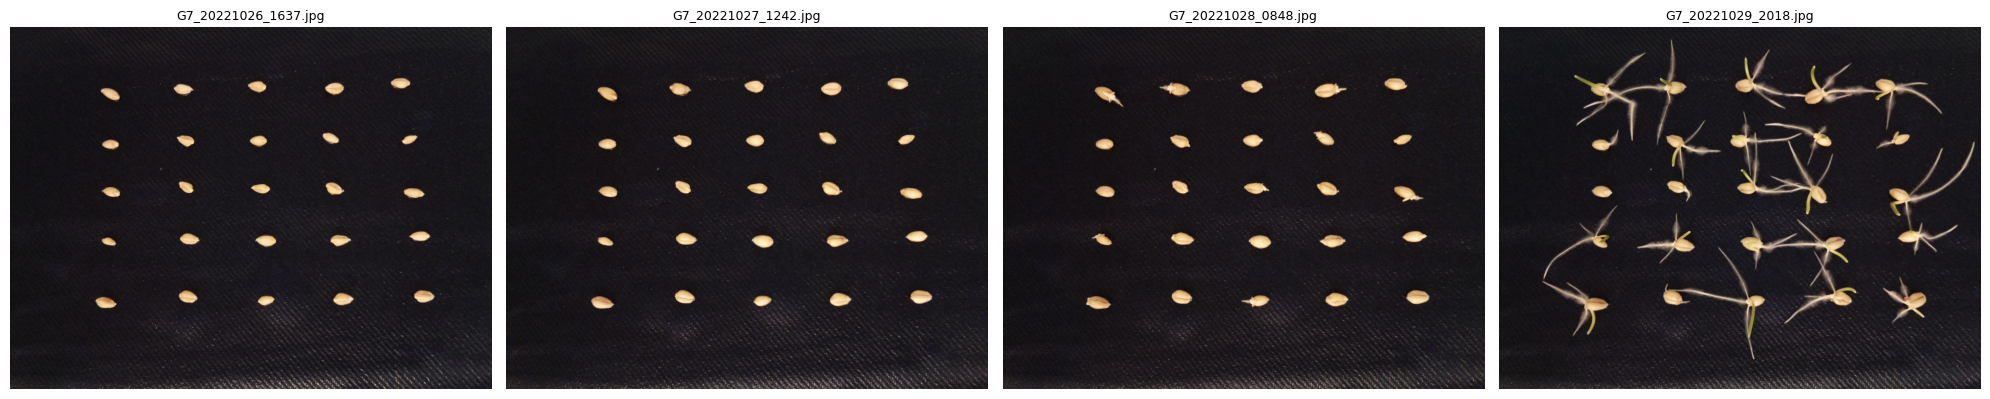

In [ ]:
import matplotlib.pyplot as plt
from skimage import io
files = sorted(os.listdir("/content/SeedGerm-VIG/example_G7"))
print(len(files), "images:", files[0], "...", files[-1])
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, fn in zip(axes, [files[0], files[4], files[8], files[15]]):
    img = io.imread(f"/content/SeedGerm-VIG/example_G7/{fn}")
    ax.imshow(img); ax.set_title(fn, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## Step 1 — U-Net mask prediction (overall / seed / seedling)

Author's prediction loop from `Step_1-mask_prediction.ipynb` (verbatim body): letterbox-resize to
512×512 with gray padding, preprocess `x/127.5 − 1`, predict, crop back, upsample to original
size, `argmax` → mask PNG saved to `./model_predict/G7_*/`. Runs 3 models × 16 images.
`# ADAPTATION`: the three identical author loops are wrapped in one parameterized function
(behavior-preserving); the Keras/SavedModel handle is used uniformly.


In [ ]:
# Author Step_1 preprocessing functions (verbatim)
def resize_image(image, size):
    iw, ih  = image.size
    w, h    = size

    scale   = min(w/iw, h/ih)
    nw      = int(iw*scale)
    nh      = int(ih*scale)

    image   = image.resize((nw,nh), Image.BICUBIC)
    new_image = Image.new('RGB', size, (128,128,128))
    new_image.paste(image, ((w-nw)//2, (h-nh)//2))

    return new_image, nw, nh
    
def preprocess_input(image):
    image = image / 127.5 - 1
    return image

def predict_masks(model_loaded, input_dir, out_dir, input_shape=(512, 512)):
    """Author Step_1 prediction loop, verbatim except parameterized dirs.
    Source: Step_1-mask_prediction.ipynb code cells 5/9/13 (identical modulo dir names).
    """
    import os, numpy as np, cv2
    from PIL import Image
    from skimage import io
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    for tmp_file in os.listdir(input_dir):
        image = Image.open(os.path.join(input_dir, tmp_file))
        original_h, original_w = np.array(image).shape[:2]
        image_data, nw, nh  = resize_image(image, (input_shape[1], input_shape[0]))
        image_data  = np.expand_dims(preprocess_input(np.array(image_data, np.float32)), 0)
        pr = model_loaded.predict(image_data)[0]
        pr = pr[int((input_shape[0] - nh) // 2) : int((input_shape[0] - nh) // 2 + nh), \
                    int((input_shape[1] - nw) // 2) : int((input_shape[1] - nw) // 2 + nw)]
        pr = cv2.resize(pr, (original_w, original_h), interpolation = cv2.INTER_LINEAR)
        pr = pr.argmax(axis=-1)
        
        img_prefix = tmp_file.split('.')[0]
        io.imsave(os.path.join(out_dir, f'{img_prefix}.png'), pr.astype(np.uint8))  # ADAPTATION: PNG needs uint8


os.chdir("/content/SeedGerm-VIG")  # ADAPTATION: author notebooks use relative ./ paths

for key in ["overall", "seed", "seedling"]:
    m, src = MODELS[key]
    out_dir = f"./model_predict/G7_{key}/"
    input_shape = (512, 512)
    if src == "saved_model":
        # Author loop verbatim, prediction via the verified serving signature
        sig = m.signatures.get("serving_default") or list(m.signatures.values())[0]
        import numpy as np, cv2
        from PIL import Image
        from skimage import io
        os.makedirs(out_dir, exist_ok=True)
        for tmp_file in sorted(os.listdir("./example_G7/")):
            image = Image.open(os.path.join("./example_G7", tmp_file))
            original_h, original_w = np.array(image).shape[:2]
            image_data, nw, nh = resize_image(image, (input_shape[1], input_shape[0]))
            image_data = np.expand_dims(np.array(image_data, np.float32) / 127.5 - 1, 0)
            pr = list(sig(tf.convert_to_tensor(image_data)).values())[0].numpy()[0]
            pr = pr[int((input_shape[0] - nh) // 2): int((input_shape[0] - nh) // 2 + nh),
                    int((input_shape[1] - nw) // 2): int((input_shape[1] - nw) // 2 + nw)]
            pr = cv2.resize(pr, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
            pr = pr.argmax(axis=-1)
            io.imsave(os.path.join(out_dir, tmp_file.split('.')[0] + '.png'), pr.astype(np.uint8))  # ADAPTATION: PNG needs uint8
    else:
        predict_masks(m, "./example_G7/", out_dir, input_shape)
    print(f"[{key}] masks written:", len(os.listdir(out_dir)))
stage("step1 U-Net masks")

/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_overall/G7_20221026_1637.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_overall/G7_20221026_2138.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_overall/G7_20221027_0239.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_overall/G7_20221027_0741.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_overall/G7_20221027_1242.png is a low contrast image
  return func(*args, **kwargs)


...

/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_seedling/G7_20221029_0454.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_seedling/G7_20221029_0955.png is a low contrast image
  return func(*args, **kwargs)


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_seedling/G7_20221029_1457.png is a low contrast image
  return func(*args, **kwargs)


[seedling] masks written: 16
[stage] step1 U-Net masks: 71 s since start


/usr/local/lib/python3.13/dist-packages/skimage/_shared/utils.py:328: UserWarning: ./model_predict/G7_seedling/G7_20221029_2018.png is a low contrast image
  return func(*args, **kwargs)


## Step 2.1 — YOLOv8x-Germ germination-phase detection

Author `Step_2.1-phase_detection.ipynb` verbatim (one bug fix, marked): per-frame detections are
pickled to `./model_predict/G7_phase/*.pkl` for the correction step. Classes: 0=IMB (imbibition),
1=PRO (protrusion), 2=RE (radicle emergence), 3=SE (seedling establishment).

`# ADAPTATION (required)`: the author cell text is executed in a clean Python subprocess with
`cwd=/content/SeedGerm-VIG`. Reason (observed, reproducible): after TensorFlow has used the T4 in
this kernel, an in-kernel PyTorch/ultralytics inference call never returns (CUDA context
conflict); a subprocess gets a fresh CUDA context and completes in seconds. The code text,
weights, images and outputs are identical; only the process boundary was added. The pickled
`ultralytics` Boxes objects are verified to unpickle in the main kernel afterwards.


In [ ]:
import subprocess, sys, os
step21_script = 'from ultralytics import YOLO\nimport skimage\nimport pickle\nimport os\nmodel = YOLO(\'./models/YOLOv8x-Germ.pt\') \ntarget_dir = \'./example_G7/\'\nsave_dir = \'./model_predict/G7_phase/\'\nif not os.path.exists(save_dir):\n    os.makedirs(save_dir)  # ADAPTATION: os.mkdirs does not exist\nfor tmp_file in os.listdir(target_dir):\n    # detect using YOLO\n    results = model(os.path.join(target_dir, tmp_file))\n    \n    # get ROI (bounding box) data\n    ROI = results[0].boxes\n    \n    # save in pickle format for later treatment\n    file_prefix = tmp_file.split(\'.\')[0]\n    file_out = open(os.path.join(save_dir, f\'{file_prefix}.pkl\'), \'wb\')\n    pickle.dump(ROI, file_out)\nprint("phase pkls:", len(os.listdir(save_dir)))\n'
script_path = "/content/SeedGerm-VIG/step2_1_phase_detection.py"
with open(script_path, "w") as f:
    f.write(step21_script)
r = subprocess.run([sys.executable, script_path], cwd="/content/SeedGerm-VIG",
                   timeout=1800)  # streams the author prints below
assert r.returncode == 0, f"Step_2.1 subprocess failed: {r.returncode}"

# verify the Boxes pickles unpickle in this kernel
import pickle
ROI = pickle.load(open("./model_predict/G7_phase/G7_20221026_1637.pkl", "rb"))
print("unpickle OK:", len(ROI), "boxes; first conf", float(ROI[0].conf.tolist()[0]))
stage("step2.1 YOLO phase detection")

unpickle OK: 25 boxes; first conf 0.8959546089172363
[stage] step2.1 YOLO phase detection: 86 s since start


## Step 2.2 — Temporal phase correction & quantification (seed → seed-lot)

Author `Step_2.2-phase_correction_&_quantification.ipynb` verbatim: links each YOLO box to its
seed across frames using mask overlap tracking, corrects phase labels over time, exports
`traits/phase/phase_seed-level.csv` (16 frames × 25 seeds) and `phase_seedlot-level.csv`
(first frame index where ≥75% of seeds reached PRO / RE / SE), plus per-frame ROI overlays.


In [ ]:
import os
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
from skimage.morphology import disk, remove_small_objects, binary_opening
from scipy import ndimage as ndi
from skimage.measure import regionprops
import pandas as pd
import matplotlib.patches as patches
import pickle
class class_seed:
    def __init__(self):
        self.seed_flag = 0  # check whether the seed is in imbibition stage or germination stage
        self.seed_coords = ''
        self.yolo_box = ''
        self.yolo_conf = ''
        self.yolo_label = ''

    def update_seed_coords(self, seedcoat_coords):
        self.seed_coords = seedcoat_coords
    
    def update_yolo(self, yolo_box, yolo_conf, yolo_label):
        self.yolo_box = yolo_box
        self.yolo_conf = yolo_conf
        self.yolo_label = yolo_label
color_dict = {
    0:'red', # IMB (imbibition)
    1:'blue', # PRO (protrusion)
    2:'green', # RE (radicle emergence)
    3:'orange', # SE (seedling establishment)
}
input_dir = './example_G7/'
out_dir = './traits/phase'
yolo_adjust_dir = './traits/roi_adjust'
mask_overall_dir = './model_predict/G7_overall/'
mask_seed_dir = './model_predict/G7_seed/'
yolo_pickle_dir = './model_predict/G7_phase/'
row_num = 5
col_num = 5
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
if not os.path.exists(yolo_adjust_dir):
    os.makedirs(yolo_adjust_dir)
files = sorted(os.listdir(input_dir))
seed_class_list = []
previous_mask = ''
seed_num = 0
box_posess = []

The main correction loop (author cell, runs over all 16 frames; a few minutes):

主ループ(著者コードのまま。16 フレームを処理します)。


In [ ]:
for file_index, file_name in enumerate(files):
    print('*' * 40 + file_name + '*' * 40)
    file_prefix = file_name.split('.')[0]
    tmp_f = open(os.path.join(yolo_pickle_dir, f'{file_prefix}.pkl'), 'rb')
    tmp_yolo_box = pickle.load(tmp_f)
    tmp_yolo_box = [box for box in tmp_yolo_box if box.conf >= 0.5]
    box_possess = [0 for box in tmp_yolo_box]
    seed_mask = io.imread(os.path.join(mask_seed_dir, file_prefix+'.png')) > 0
    seed_mask = binary_opening(seed_mask, disk(2))
    image_origion = io.imread(os.path.join(input_dir, file_name))
    if file_index == 0:  # 1st image of the time series data
        label_seed, label_num = ndi.label(seed_mask)
        seed_num = label_num
        seed_class_list = [class_seed() for _ in range(seed_num)]
        centroid_rr, centroid_cc, seedregion_list = [], [], []
        for tmp_region in regionprops(label_seed):
            rr, cc = tmp_region.centroid
            centroid_rr.append(int(rr))
            centroid_cc.append(int(cc))
            seedregion_list.append(tmp_region)
        
        # sort & give each seed an ID
        data = {'cen_r': centroid_rr, 'cen_c': centroid_cc, 'seed_props': seedregion_list}
        cen_df = pd.DataFrame(data)
        df1 = cen_df[0:col_num].sort_values(by=['cen_c'])
        for i in range(1, row_num):
            temp = cen_df[i * col_num:(i + 1) * col_num].sort_values(by=['cen_c'])
            df1 = pd.concat([df1, temp], axis=0)
        df1 = df1.reset_index(drop=True)
        
        for i in range(label_num):
            seed_temp = df1.loc[i, 'seed_props']
            seed_class_list[i].update_seed_coords(seed_temp.coords)

            box_candidate_index = []
            box_overlap_area = []
            box_coords = []
            box_conf = []
            box_label = []
            for box_index, box in enumerate(tmp_yolo_box):
                box_coord = box.xyxy.tolist()[0]
                left, top, right, bottom = [int(m) for m in box_coord]
                tmp_box_mask = np.zeros(seed_mask.shape)
                tmp_box_mask[top:bottom+1, left:right+1]=1
                single_seed_mask_full = np.zeros(seed_mask.shape)
                single_seed_mask_full[seed_temp.coords[:,0], seed_temp.coords[:,1]] = 1
                new_overlap_mask = tmp_box_mask * single_seed_mask_full
                overlap_pixel_num = np.sum(new_overlap_mask)
                if overlap_pixel_num > 0:
                    box_candidate_index.append(box_index)
                    box_overlap_area.append(overlap_pixel_num)
                    box_conf.append(box.conf.tolist()[0])
                    box_label.append(box.cls.tolist()[0])
                    box_coords.append([left, top, right, bottom])
            if len(box_overlap_area) > 0:
                box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                chosen_index = box_conf_sort[0]
                seed_class_list[i].update_yolo(box_coords[chosen_index], box_conf[chosen_index], box_label[chosen_index])

        previous_mask = seed_mask
        
        fig, ax = plt.subplots()
        plt.axis('off')
        ax.imshow(image_origion)
        for tmp_i in range(len(seed_class_list)):
            left, top, right, bottom = seed_class_list[tmp_i].yolo_box
            label_tmpbox = seed_class_list[tmp_i].yolo_label
            conf_tmpbox = seed_class_list[tmp_i].yolo_conf
            tmp_color = color_dict[label_tmpbox]
            width = right - left
            height = bottom - top
            ax.add_patch(
                patches.Rectangle((left, top), width, height, edgecolor=tmp_color, fill=False)
            )
            plt.text(left+5, top-10, 
                round(conf_tmpbox,2), 
                color='white', 
                fontsize=5, 
                fontweight='bold', 
                ha='left', 
                bbox=dict(facecolor=tmp_color, edgecolor='none', pad=1.5))

        plt.savefig(os.path.join(out_dir, file_name), dpi=300, bbox_inches='tight', pad_inches=0)
        plt.close() 
        
        with open(os.path.join(yolo_adjust_dir, f'{file_prefix}.pkl'), 'wb') as f_pickle:
            pickle.dump(seed_class_list, f_pickle)
        
        continue

    overall_mask = io.imread(os.path.join(mask_overall_dir, file_prefix+'.png')) > 0

    sub = np.logical_and(overall_mask, np.logical_not(seed_mask))
    sub2 = remove_small_objects(sub, 50)
    protrusion_flag = 1 if np.any(sub2 == 1) else 0

    if protrusion_flag == 0:  # imbibed seeds
        # relocalize seed
        mask_and = previous_mask * seed_mask
        tmp_overlap_img, tmp_overlap_num = ndi.label(mask_and)
        overlap_region_list = [region.coords[0] for region in regionprops(tmp_overlap_img)]

        seed_new_list = [_ for _ in regionprops(ndi.label(seed_mask)[0])]

        trans_dict = {}
        for i in range(seed_num):
            for rr, cc in overlap_region_list:
                if (rr, cc) not in trans_dict and \
                        np.any((seed_class_list[i].seed_coords == [rr, cc]).all(axis=1) == 1):
                    trans_dict[rr, cc] = i
                    break

        trans_new = {}
        for region_index, region_props in enumerate(seed_new_list):
            origin_seed_num = []
            for (rr, cc) in trans_dict.keys():
                if np.any((region_props.coords == [rr, cc]).all(axis=1) == 1):
                    origin_seed_num.append(trans_dict[rr, cc])
            origin_seed_num = list(set(origin_seed_num))
            if len(origin_seed_num) == 1:  # 唯一匹配
                trans_new[region_index] = origin_seed_num[0]

        for tmp_region_index, tmp_seed_same in trans_new.items():
            seed_class_list[tmp_seed_same].update_seed_coords(seed_new_list[tmp_region_index].coords)

            box_candidate_index = []
            box_overlap_area = []
            box_coords = []
            box_conf = []
            box_label = []
            for box_index, box in enumerate(tmp_yolo_box):
                if box_possess[box_index] > 0:
                    continue
                box_coord = box.xyxy.tolist()[0]
                left, top, right, bottom = [int(m) for m in box_coord]
                tmp_box_mask = np.zeros(seed_mask.shape)
                tmp_box_mask[top:bottom+1, left:right+1]=1
                single_seed_mask_full = np.zeros(seed_mask.shape)
                seed_coords = seed_class_list[tmp_seed_same].seed_coords
                single_seed_mask_full[seed_coords[:,0], seed_coords[:,1]] = 1
                new_overlap_mask = tmp_box_mask * single_seed_mask_full
                overlap_pixel_num = np.sum(new_overlap_mask)
                if overlap_pixel_num >= 0.85 * len(seed_coords):
                    box_candidate_index.append(box_index)
                    box_overlap_area.append(np.sum(tmp_box_mask * overall_mask))
                    box_coords.append([left, top, right, bottom])
                    box_conf.append(box.conf.tolist()[0])
                    box_label.append(box.cls.tolist()[0])
            if len(box_overlap_area) > 0:
                box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                chosen_index = box_conf_sort[0]
                seed_class_list[tmp_seed_same].update_yolo(box_coords[chosen_index], box_conf[chosen_index], box_label[chosen_index])
                box_possess[box_candidate_index[chosen_index]] = 1
    else:
        seed_new_list, seed_centroid_list = [], []
        for _ in regionprops(ndi.label(seed_mask)[0]):
            overlap_mask = np.zeros(overall_mask.shape)
            overlap_mask[_.coords[:, 0], _.coords[:, 1]] = 1
            overlap_mask = np.logical_and(previous_mask * overlap_mask, overall_mask)
            overlap_mask = remove_small_objects(overlap_mask, 50)
            if len(np.argwhere(overlap_mask > 0)) == 0: 
                continue
            seed_new_list.append(_)
            seed_centroid_list.append(np.argwhere(overlap_mask > 0)[0])

        trans_dict = {}
        for i in range(seed_num):
            for [rr, cc] in seed_centroid_list:
                if (rr, cc) not in trans_dict and \
                        np.any((seed_class_list[i].seed_coords == [rr, cc]).all(axis=1) == 1):
                    trans_dict[(rr, cc)] = i

        trans_new = {}
        for region_index, region_props in enumerate(seed_new_list):
            origin_seed_num = []
            for (rr, cc) in trans_dict.keys():
                if np.any((region_props.coords == [rr, cc]).all(axis=1) == 1):
                    origin_seed_num.append(trans_dict[(rr, cc)])
            origin_seed_num = list(set(origin_seed_num))
            if len(origin_seed_num) == 1:
                trans_new[region_index] = origin_seed_num[0]

        for tmp_region in regionprops(ndi.label(overall_mask)[0]):
            overlap_num = []
            tmp_coords = tmp_region.coords
            for point_index, point in enumerate(seed_centroid_list):
                rr, cc = point
                if np.any((tmp_coords == [rr, cc]).all(axis=1) == 1):
                    overlap_num.append(trans_new[point_index])
            if len(overlap_num) == 1:  # no overlap conditions
                tmp_region_index, tmp_seed_same = '', ''
                for temp_region_index, temp_seed_same in trans_new.items():
                    if temp_seed_same == overlap_num[0]:
                        tmp_region_index = temp_region_index
                        tmp_seed_same = overlap_num[0]
                        break
                seed_class_list[tmp_seed_same].update_seed_coords(seed_new_list[tmp_region_index].coords)
                temp_single_seed_mask = np.zeros(seed_mask.shape)
                temp_single_seed_mask[seed_new_list[tmp_region_index].coords[:, 0],
                seed_new_list[tmp_region_index].coords[:, 1]] = 1

                box_candidate_index = []
                box_overlap_area = []
                box_coords = []
                box_conf = []
                box_label = []
                for box_index, box in enumerate(tmp_yolo_box):
                    if box_possess[box_index] > 0:
                        continue
                    box_coord = box.xyxy.tolist()[0]
                    left, top, right, bottom = [int(m) for m in box_coord]
                    tmp_box_mask = np.zeros(seed_mask.shape)
                    tmp_box_mask[top:bottom+1, left:right+1]=1
                    new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                    overlap_pixel_num = np.sum(new_overlap_mask)
                    if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                        a, b = ndi.label(tmp_box_mask * seed_mask)
                        if b > 1:
                            previous_box_mask = np.zeros(seed_mask.shape) 
                            left_p, top_p, right_p, bottom_p = seed_class_list[tmp_seed_same].yolo_box
                            previous_box_mask[top_p:bottom_p+1, left_p:right_p+1]=1
                            box_overlap = tmp_box_mask * previous_box_mask
                            if np.sum(box_overlap) < 0.7 * np.sum(tmp_box_mask):
                                continue
                        box_candidate_index.append(box_index)
                        box_overlap_area.append(np.sum(tmp_box_mask * overall_mask))
                        box_coords.append([left, top, right, bottom])
                        box_conf.append(box.conf.tolist()[0])
                        box_label.append(box.cls.tolist()[0])
                if len(box_overlap_area) > 0:
                    box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                    chosen_index = box_conf_sort[0]
                    seed_class_list[tmp_seed_same].update_yolo(box_coords[chosen_index], box_conf[chosen_index], box_label[chosen_index])
                    box_possess[box_candidate_index[chosen_index]] = 1
            elif len(overlap_num) == 0:
                continue
            else: # intersections
                tmp_seed_dict = {}
                tmp_seed_mask = np.zeros(seed_mask.shape)
                tmp_seedling_mask = np.zeros(seed_mask.shape)
                tmp_seedling_mask[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
                overlap_num_seedmask = []
                overlap_num_flag = []
                for tmp_seed_index, tmp_seed_num in enumerate(overlap_num):
                    tmp_seed_dict[tmp_seed_num] = {}
                    tmp_region_index, tmp_seed_same = '', ''
                    for temp_region_index, temp_seed_same in trans_new.items():
                        if temp_seed_same == tmp_seed_num:
                            tmp_region_index = temp_region_index
                            tmp_seed_same = tmp_seed_num
                            tmp_seed_dict[tmp_seed_num] = tmp_seed_same
                            break

                    seed_class_list[tmp_seed_same].update_seed_coords(
                        seed_new_list[tmp_region_index].coords)
                    temp_single_seed_mask = np.zeros(seed_mask.shape)
                    temp_single_seed_mask[seed_new_list[tmp_region_index].coords[:, 0],
                    seed_new_list[tmp_region_index].coords[:, 1]] = 1
                    overlap_num_seedmask.append(temp_single_seed_mask)

                    box_candidate_index = []
                    box_overlap_area = []
                    box_coords = []
                    box_conf = []
                    box_label = []
                    for box_index, box in enumerate(tmp_yolo_box):
                        if box_possess[box_index] > 0:
                            continue
                        box_coord = box.xyxy.tolist()[0]
                        left, top, right, bottom = [int(m) for m in box_coord]
                        tmp_box_mask = np.zeros(seed_mask.shape)
                        tmp_box_mask[top:bottom+1, left:right+1]=1
                        previous_box = np.zeros(seed_mask.shape)
                        pre_left, pre_top, pre_right, pre_bottom = seed_class_list[tmp_seed_same].yolo_box
                        previous_box[pre_top:pre_bottom+1, pre_left:pre_right+1]=1
                        new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                        overlap_pixel_num = np.sum(new_overlap_mask)
                        if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                            a, b = ndi.label(tmp_box_mask * seed_mask)
                            if b > 1:
                                continue
                            box_candidate_index.append(box_index)
                            box_overlap_area.append(np.sum(tmp_box_mask * previous_box)/np.sum(tmp_box_mask))
                            box_coords.append([left, top, right, bottom])
                            box_conf.append(box.conf.tolist()[0])
                            box_label.append(box.cls.tolist()[0])
                    if len(box_overlap_area) > 0:
                        box_overlap_area_sort = sorted(range(len(box_overlap_area)), key=lambda k: box_overlap_area[k], reverse=True)
                        chosen_index = box_overlap_area_sort[0]
                        seed_class_list[tmp_seed_same].update_yolo(box_coords[chosen_index], box_conf[chosen_index], box_label[chosen_index])
                        box_possess[box_candidate_index[chosen_index]] = 1
                        overlap_num_flag.append(1)
                    else:
                        overlap_num_flag.append(0)

                for tmp_seed_index, tmp_seed_num in enumerate(overlap_num):
                    if overlap_num_flag[tmp_seed_index] > 0:
                        continue
                    temp_single_seed_mask = overlap_num_seedmask[tmp_seed_index]
                    box_candidate_index = []
                    box_overlap_area = []
                    box_coords = []
                    box_conf = []
                    box_label = []
                    tmp_seed_same = tmp_seed_dict[tmp_seed_num]
                    for box_index, box in enumerate(tmp_yolo_box):
                        if box_possess[box_index] > 0:
                            continue
                        box_coord = box.xyxy.tolist()[0]
                        left, top, right, bottom = [int(m) for m in box_coord]
                        tmp_box_mask = np.zeros(seed_mask.shape)
                        tmp_box_mask[top:bottom+1, left:right+1]=1
                        previous_box = np.zeros(seed_mask.shape)
                        pre_left, pre_top, pre_right, pre_bottom = seed_class_list[tmp_seed_same].yolo_box
                        previous_box[pre_top:pre_bottom+1, pre_left:pre_right+1]=1
                        new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                        overlap_pixel_num = np.sum(new_overlap_mask)
                        if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                            box_candidate_index.append(box_index)
                            box_overlap_area.append(np.sum(tmp_box_mask * previous_box)/np.sum(tmp_box_mask))
                            box_coords.append([left, top, right, bottom])
                            box_conf.append(box.conf.tolist()[0])
                            box_label.append(box.cls.tolist()[0])
                    if len(box_overlap_area) > 0:
                        box_overlap_area_sort = sorted(range(len(box_overlap_area)), key=lambda k: box_overlap_area[k], reverse=True)
                        chosen_index = box_overlap_area_sort[0]
                        seed_class_list[tmp_seed_same].update_yolo(box_coords[chosen_index], box_conf[chosen_index], box_label[chosen_index])
                        box_possess[box_candidate_index[chosen_index]] = 1

    seed_mask_pure = np.zeros(previous_mask.shape)
    for i in range(len(seed_class_list)):
        tmp_coords = seed_class_list[i].seed_coords
        seed_mask_pure[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
    previous_mask = seed_mask_pure

    fig, ax = plt.subplots()
    plt.axis('off')
    ax.imshow(image_origion)
    for tmp_i in range(len(seed_class_list)):
        left, top, right, bottom = seed_class_list[tmp_i].yolo_box
        label_tmpbox = seed_class_list[tmp_i].yolo_label
        conf_tmpbox = seed_class_list[tmp_i].yolo_conf
        tmp_color = color_dict[label_tmpbox]
        width = right - left
        height = bottom - top
        ax.add_patch( 
            patches.Rectangle((left, top), width, height, edgecolor=tmp_color, fill=False)
        )
        plt.text(left+5, top-10, 
            round(conf_tmpbox,2), 
            color='white', 
            fontsize=5, 
            fontweight='bold', 
            ha='left', 
            bbox=dict(facecolor=tmp_color, edgecolor='none', pad=1.5))

    plt.savefig(os.path.join(out_dir, file_name), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close()  
    
    with open(os.path.join(yolo_adjust_dir, f'{file_prefix}.pkl'), 'wb') as f_pickle:
        pickle.dump(seed_class_list, f_pickle)
    
stage("step2.2 phase correction loop")

****************************************G7_20221026_1637.jpg****************************************


****************************************G7_20221026_2138.jpg****************************************


****************************************G7_20221027_0239.jpg****************************************


****************************************G7_20221027_0741.jpg****************************************


****************************************G7_20221027_1242.jpg****************************************


...

****************************************G7_20221029_0454.jpg****************************************


****************************************G7_20221029_0955.jpg****************************************


****************************************G7_20221029_1457.jpg****************************************


****************************************G7_20221029_2018.jpg****************************************


[stage] step2.2 phase correction loop: 472 s since start


Per-seed phase table from the corrected ROI pickles (rows = 16 frames, columns = 25 seed IDs;
0=IMB, 1=PRO, 2=RE, 3=SE), then saved to `traits/phase/phase_seed-level.csv`:

各フレーム・各種子の発芽段階表(0=IMB, 1=PRO, 2=RE, 3=SE)を作成・保存します。


In [ ]:
yolo_adjust_dir = './traits/roi_adjust/'
phase_single = []
for tmp_pickle in sorted(os.listdir(yolo_adjust_dir)):  # ADAPTATION
    tmp_f = open(os.path.join(yolo_adjust_dir, tmp_pickle), 'rb')
    seed_class_list = pickle.load(tmp_f)
    tmp_single = []
    for i in range(len(seed_class_list)):
        tmp_single.append(seed_class_list[i].yolo_label)
    phase_single.append(tmp_single)
phase_single_df = pd.DataFrame(phase_single)
phase_single_df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Save the seed-level phase CSV (author cell):

seed レベルのフェーズ CSV を保存します。


In [ ]:
phase_single_df.to_csv(os.path.join(out_dir, 'phase_seed-level.csv'))
print('saved phase_seed-level.csv')

saved phase_seed-level.csv


Seed-lot-level time points: first frame index where ≥75% of seeds reached each phase
(author cells), saved to `phase_seedlot-level.csv`:

ロットレベル(75% 到達時点)のタイムポイントを算出・保存します。


In [ ]:
timepoint_PRO = None
timepoint_RE = None
timepoint_SE = None

for i in range(len(phase_single_df)):
    row_data = phase_single_df.loc[i].values
    count_PRO = 0
    count_RE = 0
    count_SE = 0
    for tmp_single_phase in row_data:
        if tmp_single_phase >= 1:
            count_PRO += 1
        if tmp_single_phase >= 2:
            count_RE += 1
        if tmp_single_phase == 3:
            count_SE += 1
    proportion_PRO = count_PRO/len(row_data)
    proportion_RE = count_RE/len(row_data)
    proportion_SE = count_SE/len(row_data)
    
    if proportion_PRO >= 0.75 and timepoint_PRO is None:
        timepoint_PRO = i
    if proportion_RE >= 0.75 and timepoint_RE is None:
        timepoint_RE = i
    if proportion_SE >= 0.75 and timepoint_SE is None:
        timepoint_SE = i    
phase_seedlot_df = pd.DataFrame([timepoint_PRO, timepoint_RE, timepoint_SE])
phase_seedlot_df.columns = ['index']
phase_seedlot_df.index = ['timepoint_PRO', 'timepoint_RE', 'timepoint_SE']
phase_seedlot_df
phase_seedlot_df.to_csv(os.path.join(out_dir, 'phase_seedlot-level.csv'))

## Step 3 — Root-tip tracking & trait extraction (author `Step_3` notebook)

First the author's imports and helper functions (skeleton branch/end-point detection, seed
tracking class, graph utilities) — copied verbatim. The main loop then re-identifies seeds per
frame, builds a temporal directed graph of root tips from skeleton fragments, and accumulates
per-root growth increments (`root_growth_rate_dict`), saving root-tracking overlay figures.


In [ ]:
import os
import matplotlib.pyplot as plt
from skimage import io, color
import numpy as np
from skimage import util
from skimage.morphology import binary_dilation, disk, remove_small_objects, skeletonize,binary_opening, remove_small_holes, binary_erosion
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from scipy.ndimage import binary_hit_or_miss
from skimage.measure import regionprops
from skimage.graph import route_through_array
import pandas as pd
import math
from skimage.transform import resize
import sys
from skimage.draw import line
from skimage.filters import threshold_otsu, threshold_mean
import pickle
def cutout_plant_from_original(img, binary_final_img):
    mask = binary_final_img > 0

    r = img[:, :, 0] * mask
    g = img[:, :, 1] * mask
    b = img[:, :, 2] * mask

    img_temp = np.dstack([r, g, b])

    return img_temp
def find_branches(skel):
    """Detect branching points of a skeleton"""
    # Five possible matrix representation
    struct1 = np.array([[0, 1, 0], [0, 1, 0], [1, 0, 1]])
    struct2 = np.array([[1, 0, 0], [0, 1, 1], [0, 1, 0]])
    struct3 = np.array([[1, 0, 0], [0, 1, 0], [1, 0, 1]])
    struct4 = np.array([[0, 0, 0], [1, 1, 1], [0, 1, 0]])
    struct5 = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])

    # Match branching point structures with the skeleton
    structs = [np.rot90(struct1, i)
               for i in range(4)]
    structs += [np.rot90(struct2, i) for i in range(4)]
    structs += [np.rot90(struct3, i) for i in range(4)]
    structs += [np.rot90(struct4, i) for i in range(4)]
    structs += [np.rot90(struct5, i) for i in range(4)]

    ret = None
    for i in range(len(structs)):
        if ret is None:
            ret = binary_hit_or_miss(skel, structure1=structs[i])
        else:
            ret = np.logical_xor(
                ret, binary_hit_or_miss(skel, structure1=structs[i]))
    return np.transpose(np.nonzero(ret))
def find_end_points(skel):
    """Detect end points of a skeleton"""
    # Four possible matrix representation
    struct1, origin1 = np.array([
        [0, 0, 0],
        [0, 1, 0],
    ]), (0, 0)
    struct2, origin2 = np.array([
        [0, 0],
        [0, 1],
        [0, 0],
    ]), (0, 0)
    struct3, origin3 = np.array([
        [0, 1, 0],
        [0, 0, 0],
    ]), (-1, 0)
    struct4, origin4 = np.array([
        [0, 0],
        [1, 0],
        [0, 0],
    ]), (0, -1)

    struct_except = np.array([[0, 0, 1], [0, 1, 0], [0, 0, 1]])
    struct_excepts = [np.rot90(struct_except, i) for i in range(4)]

    # Match end point structures with the skeleton
    ret = None
    for i in range(1, 5):
        struct, origin = locals()['struct%d' %
                                  (i)], locals()['origin%d' %
                                                 (i)] 
        if ret is None:
            ret = binary_hit_or_miss(skel, structure1=struct,
                                     origin1=origin)  
        else:
            ret = np.logical_or(
                ret, binary_hit_or_miss(skel,
                                        structure1=struct,
                                        origin1=origin))

    ret_temp = None
    for i in range(len(struct_excepts)):
        if ret_temp is None:
            ret_temp = binary_hit_or_miss(skel, structure1=struct_excepts[i])
        else:
            ret_temp = np.logical_xor(
                ret_temp, binary_hit_or_miss(skel,
                                             structure1=struct_excepts[i]))

    ret = np.logical_and(ret, np.logical_not(ret_temp))
    return np.transpose(np.nonzero(ret))
def get_rgb_color(seed_mask, seed_img):

    r, g, b = seed_img[:,:,0], seed_img[:,:,1], seed_img[:,:,2]
    r_mean = np.sum(seed_mask * r) / np.sum(seed_mask)
    g_mean = np.sum(seed_mask * g) / np.sum(seed_mask)
    b_mean = np.sum(seed_mask * b) / np.sum(seed_mask)

    return r_mean, g_mean, b_mean
def get_ske(seed_mask, show_result=False):
    ske = skeletonize(seed_mask)
    ske_temp = ske.copy()
    store_list = []
    branch_points = find_branches(ske)
    for point in branch_points:
        temp = ske[point[0] - 1:point[0] + 2,
                        point[1] - 1:point[1] + 2].copy()
        store_list.append(temp)
        ske_temp[point[0] - 1:point[0] + 2, point[1] - 1:point[1] + 2] = 0

    end_points = find_end_points(ske)

    struct = [[1, 1, 1], [1, 1, 1], [1, 1, 1]]
    ske_label, _ = ndi.label(ske_temp, structure=struct)
    ske_regions = regionprops(ske_label)
    for region in ske_regions:
        flag = 1
        for end_point in end_points:
            if flag:
                if region.area < 5 and np.any(
                    (region.coords == end_point).all(axis=1) == 1):
                    ske_temp[region.coords[:, 0], region.coords[:, 1]] = 0
                    flag = 0

    for point_index, point in enumerate(branch_points):
        ske_temp[point[0] - 1:point[0] + 2,
                 point[1] - 1:point[1] + 2] = store_list[point_index]

    new_end_points = find_end_points(ske_temp)
    for [end_i, end_j] in new_end_points:
        flag = 1
        for [branch_i, branch_j] in branch_points:
            if flag:
                if (branch_i - end_i)**2 + (branch_j - end_j)**2 < 4:
                    ske_temp[end_i, end_j] = 0
                    flag = 0

    if (show_result):
        fig, ax = plt.subplots(2, 1, figsize=(20, 20))
        ax[0].imshow(ske)
        ax[1].imshow(ske_temp)
        plt.show()
        plt.close()

    return ske_temp
class class_seed:
    def __init__(self):
        self.seed_flag = 0  # check whether the seed is in imbibition stage or germination stage
        self.overlap_flag = 0
        self.seed_coords = ''
        ## germination traits
#         self.root_length_dict = {}
        self.root_growth_rate_dict = {}
        self.root_num = 0
        self.root_endpoint_dict = {}
        self.root_startpoint_dict = {}
        self.root_flag_dict = {}
        self.root_update_flag_dict = {}
        self.reconstruction_ske = {}
        ## imbibition traits
        self.length_list = []
        self.width_list = []
        self.area_list = []
        self.perimeter_list = []
        self.roundness_list = []
        self.wl_ratio = []
        self.color_dict = {
            'R':[],
            'G':[],
            'B':[],
        }
        ## green related
        self.seedling_trans = ''
        self.seedling_emergence = ''
        self.seedling_len = []
        
        self.cls = []
        self.yolo_box = ''
        
    def reset_root_update_flag(self, value=0):
        for tmp_key in self.root_update_flag_dict:
            self.root_update_flag_dict[tmp_key] = value

    def update_seed_flag(self, value=0):
        self.seed_flag = value

    def update_seed_coords(self, seedcoat_coords):
        self.seed_coords = seedcoat_coords

    def update_root_endpoint(self, num, endpoint):
        self.root_endpoint_dict[num] = endpoint

    def update_root_startpoint(self, num, startpoint):
        self.root_startpoint_dict[num] = startpoint

    def update_seed_centroid(self, seed_centroid):
        self.seed_centroid = seed_centroid

    def store_seedpheno(self, length, width, area, perimeter, roundness,wl_ratio, color_list):
        self.length_list.append(length)
        self.width_list.append(width)
        self.area_list.append(area)
        self.perimeter_list.append(perimeter)
        self.roundness_list.append(roundness)
        self.wl_ratio.append(wl_ratio)
        self.color_dict['R'].append(color_list[0])
        self.color_dict['G'].append(color_list[1])
        self.color_dict['B'].append(color_list[2])

    def update_root_length(self, num, length, img_index=''):
        if img_index == '':  # 根长数据更新
#             self.root_length_dict[num].append(length)
            self.root_growth_rate_dict[num].append(length)
        else:
#             self.root_length_dict[num] = [0] * img_index
            self.root_growth_rate_dict[num] = [0] * img_index
#             self.root_length_dict[num].append(length)
            self.root_growth_rate_dict[num].append(length)

    def store_reconstruction_ske(self, num, tmp_rr, tmp_cc, img_index=''):
        if img_index == '':  # 根长数据更新
            self.reconstruction_ske[num]['rr'].append(tmp_rr)
            self.reconstruction_ske[num]['cc'].append(tmp_cc)
        else:
            self.reconstruction_ske[num] = {'rr': [], 'cc': []}
            self.reconstruction_ske[num]['rr'].extend([[''] for _ in range(img_index)])
            self.reconstruction_ske[num]['cc'].extend([[''] for _ in range(img_index)])
            self.reconstruction_ske[num]['rr'].append(tmp_rr)
            self.reconstruction_ske[num]['cc'].append(tmp_cc)
def compute_vec_angle(x1, x2):
    num1 = x1[0] * x2[0] + x1[1] * x2[1]
    num2 = pow(x1[0]**2 + x1[1]**2, 0.5)
    num3 = pow(x2[0]**2 + x2[1]**2, 0.5)

    return num1 / (num2 * num3)

def get_min_distance(points1,points2):
    min_distance=10000
    index1 = -1
    index2 = -1
    for i in range(len(points1)):
        for j in range(len(points2)):
            distance=pow(((points1[i][0]-points2[j][0])**2+(points1[i][1]-points2[j][1])**2),0.5)
            if(distance<min_distance):
                min_distance=distance
                index1=i
                index2=j
    return min_distance,index1,index2

def remove_d_dist_points(crossovers, d):
    min_dist = 1
    while (0 <= min_dist < d):
        if len(crossovers) == 1:
            break
        min_dist = -1
        index1 = -1
        index2 = -1
        for i in range(len(crossovers) - 1):
            for j in range(i + 1, len(crossovers)):
                x_diff = abs(crossovers[i][0] - crossovers[j][0])
                y_diff = abs(crossovers[i][1] - crossovers[j][1])
                if x_diff < d and y_diff < d:
                    min_dist = min(x_diff, y_diff)
                    index1 = i
                    inxex2 = j
                    break
            if min_dist >= 0:
                crossovers = np.delete(crossovers, index1, axis=0)
                break

    return np.array(crossovers)

Author Step_3 initialization (directories, marker styles) plus pre-created figure folders:

Step_3 の初期化(ディレクトリ等)です。


In [ ]:
input_dir = './example_G7/'
out_dir = './traits/traits/'
mask_overall_dir = './model_predict/G7_overall/'
mask_seed_dir = './model_predict/G7_seed/'
mask_seedling_dir = './model_predict/G7_seedling/'
yolo_pickle_dir = './model_predict/G7_phase/'
row_num = 5
col_num = 5
color_dict = {1: 'ro', 2: 'wo', 3: 'go', 4: 'co', 5: 'yo', 6: 'mo', 7: 'ro', }
# ADAPTATION: pre-create the author's figure output directories
os.makedirs(os.path.join(out_dir, 'root_mask'), exist_ok=True)
os.makedirs(os.path.join(out_dir, 'root_mask2'), exist_ok=True)

The main trait-extraction / root-tracking loop (author cell, verbatim; the longest step —
skeleton pruning via hit-or-miss over 24 structuring elements per frame on ~2736×1824 masks):

根端追跡の主ループ(著者コードのまま。計算量が最大のステップです)。


In [ ]:
files = sorted(os.listdir(input_dir))
seed_class_list = []
previous_mask = ''
seed_num = 0
fig_out_dir = os.path.join(out_dir, 'root_mask')
fig_out_dir2 = os.path.join(out_dir, 'root_mask2')
if not os.path.exists(fig_out_dir):
    os.makedirs(fig_out_dir)
    os.makedirs(fig_out_dir2)

struct = [[1, 1, 1],
          [1, 1, 1],
          [1, 1, 1]]
d = 20

last_file_name = files[-1]
image_origion = io.imread(os.path.join(input_dir, last_file_name))
image_origion = util.img_as_ubyte(
    resize(image_origion, (image_origion.shape[0] / 2, image_origion.shape[1] / 2), anti_aliasing=True))
last_file_prefix = last_file_name.split('.')[0]
seedling_mask = io.imread(os.path.join(mask_seedling_dir, f'{last_file_prefix}.png')) > 0
seedling_mask = util.img_as_ubyte(
    resize(seedling_mask, (image_origion.shape[0], image_origion.shape[1]), anti_aliasing=False))
exg = 2 * image_origion[:,:,1] - image_origion[:,:,0] -image_origion[:,:,2]
chloroplast_biogenesis_thre = threshold_mean(exg[seedling_mask>0])


for file_index, file_name in enumerate(files):
    print('*' * 40 + file_name + '*' * 40)
    file_prefix = file_name.split('.')[0]
    tmp_f = open(os.path.join(yolo_pickle_dir, f'{file_prefix}.pkl'), 'rb')
    tmp_yolo_box = pickle.load(tmp_f)
    tmp_yolo_box = [box for box in tmp_yolo_box if box.conf >= 0.5]
    box_possess = [0 for box in tmp_yolo_box]
    seed_mask = io.imread(os.path.join(mask_seed_dir, f'{file_prefix}.png')) > 0
    seed_mask = util.img_as_ubyte(
        resize(seed_mask, (seed_mask.shape[0] / 2, seed_mask.shape[1] / 2), anti_aliasing=False))
    seed_mask = binary_opening(seed_mask, disk(2))
    image_origion = io.imread(os.path.join(input_dir, file_name))
    image_origion = util.img_as_ubyte(
        resize(image_origion, (image_origion.shape[0] / 2, image_origion.shape[1] / 2), anti_aliasing=True))
    if file_index == 0:  # 1st image of the time series data
        label_seed, label_num = ndi.label(seed_mask)
        seed_num = label_num
        seed_class_list = [class_seed() for _ in range(seed_num)]
        seed_length_total = 0
        centroid_rr, centroid_cc, seedregion_list = [], [], []
        for tmp_region in regionprops(label_seed):
            seed_length_total += tmp_region.axis_major_length
            rr, cc = tmp_region.centroid
            centroid_rr.append(int(rr))
            centroid_cc.append(int(cc))
            seedregion_list.append(tmp_region)
        # sort & give each seed an ID
        data = {'cen_r': centroid_rr, 'cen_c': centroid_cc, 'seed_props': seedregion_list}
        cen_df = pd.DataFrame(data)
        df1 = cen_df[0:col_num].sort_values(by=['cen_c'])
        for i in range(1, row_num):
            temp = cen_df[i * col_num:(i + 1) * col_num].sort_values(by=['cen_c'])
            df1 = pd.concat([df1, temp], axis=0)
        df1 = df1.reset_index(drop=True)
        for i in range(label_num):
            seed_temp = df1.loc[i, 'seed_props']

            box_candidate_index = []
            box_overlap_area = []
            box_coords = []
            box_conf = []
            box_cls = []
            box_seed_mask = []
            for box_index, box in enumerate(tmp_yolo_box):
                box_coord = box.xyxy.tolist()[0]
                left, top, right, bottom = [int(m / 2) for m in box_coord]
                tmp_box_mask = np.zeros(seed_mask.shape)
                tmp_box_mask[top:bottom + 1, left:right + 1] = 1
                single_seed_mask_full = np.zeros(seed_mask.shape)
                single_seed_mask_full[seed_temp.coords[:, 0], seed_temp.coords[:, 1]] = 1
                new_overlap_mask = tmp_box_mask * single_seed_mask_full
                overlap_pixel_num = np.sum(new_overlap_mask)
                if overlap_pixel_num > 0:
                    box_candidate_index.append(box_index)
                    box_overlap_area.append(overlap_pixel_num)
                    box_conf.append(box.conf)
                    box_cls.append(box.cls.tolist()[0])
                    box_coords.append([left, top, right, bottom])
                    box_seed_mask.append(new_overlap_mask)
            if len(box_overlap_area) > 0:
                box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                chosen_index = box_conf_sort[0]
                seed_class_list[i].yolo_box = box_coords[chosen_index]
                seed_class_list[i].cls.append(box_cls[chosen_index])
                box_seed = regionprops(ndi.label(box_seed_mask[chosen_index])[0])[0]
                length = box_seed.axis_major_length
                width = box_seed.axis_minor_length
                perimeter = box_seed.perimeter
                area = box_seed.area
                roundness = 4 * math.pi * area / (perimeter * perimeter)
                wl_ratio = width / length
                minr, minc, maxr, maxc = box_seed.bbox
                single_seed_mask = seed_mask[minr:maxr, minc:maxc]
                single_seed_image = image_origion[minr:maxr, minc:maxc, :]
                tmp_color = get_rgb_color(single_seed_mask, single_seed_image)
                seed_class_list[i].store_seedpheno(length=length * 2, width=width * 2, area=area * 4,
                                                perimeter=perimeter * 2,
                                                roundness=roundness, wl_ratio=wl_ratio, color_list=tmp_color)
                seed_class_list[i].update_seed_coords(box_seed.coords)

        seed_mask_pure = np.zeros(seed_mask.shape)

        for i in range(len(seed_class_list)):
            seed_class_list[i].seedling_len.append(0)
            tmp_coords = seed_class_list[i].seed_coords
            seed_mask_pure[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
            if len(seed_class_list[i].cls) < file_index + 1:
                seed_class_list[i].cls.append(seed_class_list[i].cls[-1])

        previous_mask = seed_mask_pure
        
        fig, ax = plt.subplots(1, 1, figsize=(15, 15))
        ax.imshow(seed_mask)
        for i in range(label_num):
            ax.annotate("%d" % i, (seed_class_list[i].seed_coords[0][1], seed_class_list[i].seed_coords[0][0]),
                        color='red', fontsize=25)
            ax.plot(seed_class_list[i].seed_coords[0][1], seed_class_list[i].seed_coords[0][0], 'go')
        fig.savefig(os.path.join(fig_out_dir, 'fig_%02d_%s.png' % (file_index, file_prefix)),
                    bbox_inches='tight')
        fig.savefig(os.path.join(fig_out_dir2, 'fig_%02d_%s.png' % (file_index, file_prefix)),
                    bbox_inches='tight')
        plt.close()
        continue

    overall_mask = io.imread(os.path.join(mask_overall_dir, f'{file_prefix}.png')) > 0
    overall_mask = util.img_as_ubyte(
        resize(overall_mask, (image_origion.shape[0], image_origion.shape[1]), anti_aliasing=False))
    
    seedling_mask = io.imread(os.path.join(mask_seedling_dir, f'{file_prefix}.png')) > 0
    seedling_mask = util.img_as_ubyte(
        resize(seedling_mask, (image_origion.shape[0], image_origion.shape[1]), anti_aliasing=False))
    if np.any(seedling_mask > 0):
        seedling_mask = binary_opening(seedling_mask, disk(2))

    sub = np.logical_and(overall_mask, np.logical_not(seed_mask))
    sub2 = remove_small_objects(sub, 50)
    protrusion_flag = 1 if np.any(sub2 == 1) else 0
    
    overall_ske = get_ske(overall_mask)
    
    if protrusion_flag == 0:  
        mask_and = previous_mask * seed_mask
        tmp_overlap_img, tmp_overlap_num = ndi.label(mask_and)
        overlap_region_list = [region.coords[0] for region in regionprops(tmp_overlap_img)]

        seed_new_list = [_ for _ in regionprops(ndi.label(seed_mask)[0])]

        trans_dict = {}
        for i in range(seed_num):
            for rr, cc in overlap_region_list:
                if (rr, cc) not in trans_dict and \
                        np.any((seed_class_list[i].seed_coords == [rr, cc]).all(axis=1) == 1):
                    trans_dict[rr, cc] = i
                    break

        trans_new = {}
        for region_index, region_props in enumerate(seed_new_list):
            origin_seed_num = []
            for (rr, cc) in trans_dict.keys():
                if np.any((region_props.coords == [rr, cc]).all(axis=1) == 1):
                    origin_seed_num.append(trans_dict[rr, cc])
            origin_seed_num = list(set(origin_seed_num))
            if len(origin_seed_num) == 1:  # 唯一匹配
                trans_new[region_index] = origin_seed_num[0]
        
        for tmp_region_index, tmp_seed_same in trans_new.items():
            seed_class_list[tmp_seed_same].update_seed_coords(seed_new_list[tmp_region_index].coords)

            box_candidate_index = []
            box_overlap_area = []
            box_coords = []
            box_conf = []
            box_cls = []
            box_seed_mask = []
            for box_index, box in enumerate(tmp_yolo_box):
                if box_possess[box_index] > 0:
                    continue
                box_coord = box.xyxy.tolist()[0]
                left, top, right, bottom = [int(m / 2) for m in box_coord]
                tmp_box_mask = np.zeros(seed_mask.shape)
                tmp_box_mask[top:bottom + 1, left:right + 1] = 1
                single_seed_mask_full = np.zeros(seed_mask.shape)
                seed_coords = seed_class_list[tmp_seed_same].seed_coords
                single_seed_mask_full[seed_coords[:, 0], seed_coords[:, 1]] = 1
                new_overlap_mask = tmp_box_mask * single_seed_mask_full
                overlap_pixel_num = np.sum(new_overlap_mask)
                if overlap_pixel_num >= 0.85 * len(seed_coords):
                    box_candidate_index.append(box_index)
                    box_overlap_area.append(np.sum(tmp_box_mask * overall_mask))
                    box_coords.append([left, top, right, bottom])
                    box_conf.append(box.conf)
                    box_cls.append(box.cls.tolist()[0])
                    box_seed_mask.append(new_overlap_mask)
            if len(box_overlap_area) > 0:
                box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                chosen_index = box_conf_sort[0]
                seed_class_list[tmp_seed_same].yolo_box = box_coords[chosen_index]
                seed_class_list[tmp_seed_same].cls.append(box_cls[chosen_index])
                box_possess[box_candidate_index[chosen_index]] = 1
                
                box_seed = regionprops(ndi.label(box_seed_mask[chosen_index])[0])[0]
                length = box_seed.axis_major_length
                width = box_seed.axis_minor_length
                perimeter = box_seed.perimeter
                area = box_seed.area
                roundness = 4 * math.pi * area / (perimeter * perimeter)
                wl_ratio = width / length
                minr, minc, maxr, maxc = box_seed.bbox
                single_seed_mask = seed_mask[minr:maxr, minc:maxc]
                single_seed_image = image_origion[minr:maxr, minc:maxc, :]
                tmp_color = get_rgb_color(single_seed_mask, single_seed_image)
                seed_class_list[tmp_seed_same].store_seedpheno(length=length * 2, width=width * 2, area=area * 4,
                                                perimeter=perimeter * 2,
                                                roundness=roundness, wl_ratio=wl_ratio, color_list=tmp_color)
                seed_class_list[tmp_seed_same].update_seed_coords(box_seed.coords)
        
        # update previous_mask
        seed_mask_pure = np.zeros(previous_mask.shape)

        for i in range(len(seed_class_list)):
            tmp_coords = seed_class_list[i].seed_coords
            seed_mask_pure[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
            if len(seed_class_list[i].cls) < file_index + 1:
                seed_class_list[i].cls.append(seed_class_list[i].cls[-1])

        previous_mask = seed_mask_pure   

        for i in range(len(seed_class_list)):
            seed_class_list[i].overlap_flag = 0
            seed_class_list[i].seedling_len.append(0)

        plt.figure(figsize=(20, 20))
        plt.imshow(overall_ske)
        plt.contour(seed_mask, colors='red', linewidths=0.85)
        for tmp_i in range(len(seed_class_list)):
            if seed_class_list[tmp_i].seed_flag > 0:
                for tmp_key in seed_class_list[tmp_i].root_endpoint_dict:
                    tmp_rr, tmp_cc = seed_class_list[tmp_i].root_endpoint_dict[tmp_key]
                    key_num = tmp_key % 6 + 1
                    plt.plot(tmp_cc, tmp_rr, color_dict[key_num])
        plt.savefig(os.path.join(fig_out_dir, 'fig_%02d_%s.png' % (file_index, file_prefix)), bbox_inches='tight')
        plt.close()

        plt.figure(figsize=(20, 20))
        plt.imshow(overall_ske)
        plt.contour(seed_mask, colors='red', linewidths=0.85)
        for tmp_i in range(len(seed_class_list)):
            if seed_class_list[tmp_i].seed_flag > 0:
                for tmp_key in seed_class_list[tmp_i].root_endpoint_dict:
                    tmp_rr, tmp_cc = seed_class_list[tmp_i].root_endpoint_dict[tmp_key]
                    key_num = tmp_key % 6 + 1
                    plt.plot(tmp_cc, tmp_rr, color_dict[key_num])
                    plt.annotate(f'{tmp_i}-{tmp_key}', (tmp_cc, tmp_rr), color='white', fontsize=13)
        plt.savefig(os.path.join(fig_out_dir2, 'fig_%02d_%s.png' % (file_index, file_prefix)), bbox_inches='tight')
        plt.close()

        continue
                
    else:
        seed_new_list, seed_centroid_list = [], []
        for _ in regionprops(ndi.label(seed_mask)[0]):
            overlap_mask = np.zeros(overall_mask.shape)
            overlap_mask[_.coords[:, 0], _.coords[:, 1]] = 1
            overlap_mask = np.logical_and(previous_mask * overlap_mask, overall_mask)
            overlap_mask = remove_small_objects(overlap_mask, 50)
            if len(np.argwhere(overlap_mask > 0)) == 0: 
                continue
            seed_new_list.append(_)
            seed_centroid_list.append(np.argwhere(overlap_mask > 0)[0])

        trans_dict = {}
        for i in range(seed_num):
            for [rr, cc] in seed_centroid_list:
                if (rr, cc) not in trans_dict and \
                        np.any((seed_class_list[i].seed_coords == [rr, cc]).all(axis=1) == 1):
                    trans_dict[(rr, cc)] = i

        trans_new = {}
        for region_index, region_props in enumerate(seed_new_list):
            origin_seed_num = []
            for (rr, cc) in trans_dict.keys():
                if np.any((region_props.coords == [rr, cc]).all(axis=1) == 1):
                    origin_seed_num.append(trans_dict[(rr, cc)])
            origin_seed_num = list(set(origin_seed_num))
            if len(origin_seed_num) == 1:
                trans_new[region_index] = origin_seed_num[0]

        for tmp_region in regionprops(ndi.label(overall_mask)[0]):
            overlap_num = []
            tmp_coords = tmp_region.coords
            for point_index, point in enumerate(seed_centroid_list):
                rr, cc = point
                if np.any((tmp_coords == [rr, cc]).all(axis=1) == 1):
                    overlap_num.append(trans_new[point_index])
            if len(overlap_num) == 1:  # no overlap conditions
                # 定位
                tmp_region_index, tmp_seed_same = '', ''
                for temp_region_index, temp_seed_same in trans_new.items():
                    if temp_seed_same == overlap_num[0]:
                        tmp_region_index = temp_region_index
                        tmp_seed_same = overlap_num[0]
                        break
                seed_class_list[tmp_seed_same].update_seed_coords(seed_new_list[tmp_region_index].coords)
                temp_single_seed_mask = np.zeros(seed_mask.shape)
                temp_single_seed_mask[seed_new_list[tmp_region_index].coords[:, 0],
                                      seed_new_list[tmp_region_index].coords[:, 1]] = 1

                box_candidate_index = []
                box_overlap_area = []
                box_coords = []
                box_conf = []
                box_cls = []
                for box_index, box in enumerate(tmp_yolo_box):
                    if box_possess[box_index] > 0:
                        continue
                    box_coord = box.xyxy.tolist()[0]
                    left, top, right, bottom = [int(m / 2) for m in box_coord]
                    tmp_box_mask = np.zeros(seed_mask.shape)
                    tmp_box_mask[top:bottom + 1, left:right + 1] = 1
                    new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                    overlap_pixel_num = np.sum(new_overlap_mask)
                    if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                        a, b = ndi.label(tmp_box_mask * seed_mask)
                        if b > 1:
                            previous_box_mask = np.zeros(seed_mask.shape)
                            left_p, top_p, right_p, bottom_p = seed_class_list[tmp_seed_same].yolo_box
                            previous_box_mask[top_p:bottom_p + 1, left_p:right_p + 1] = 1
                            box_overlap = tmp_box_mask * previous_box_mask
                            if np.sum(box_overlap) < 0.7 * np.sum(tmp_box_mask):
                                continue
                        box_candidate_index.append(box_index)
                        box_overlap_area.append(np.sum(tmp_box_mask * overall_mask))
                        box_coords.append([left, top, right, bottom])
                        box_conf.append(box.conf)
                        box_cls.append(box.cls.tolist()[0])
                if len(box_overlap_area) > 0:
                    box_conf_sort = sorted(range(len(box_conf)), key=lambda k: box_conf[k], reverse=True)
                    chosen_index = box_conf_sort[0]
                    seed_class_list[tmp_seed_same].yolo_box = box_coords[chosen_index]
                    seed_class_list[tmp_seed_same].cls.append(box_cls[chosen_index])
                    box_possess[box_candidate_index[chosen_index]] = 1
            elif len(overlap_num) == 0:
                continue
            else:
                tmp_seed_dict = {}
                tmp_seed_mask = np.zeros(seed_mask.shape)
                tmp_overall_mask = np.zeros(seed_mask.shape)
                tmp_overall_mask[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
                overlap_num_seedmask = []
                overlap_num_flag = []
                for tmp_seed_index, tmp_seed_num in enumerate(overlap_num):
                    tmp_seed_dict[tmp_seed_num] = {}
                    tmp_region_index, tmp_seed_same = '', ''
                    for temp_region_index, temp_seed_same in trans_new.items():
                        if temp_seed_same == tmp_seed_num:
                            tmp_region_index = temp_region_index
                            tmp_seed_same = tmp_seed_num
                            tmp_seed_dict[tmp_seed_num] = tmp_seed_same
                            break

                    seed_class_list[tmp_seed_same].update_seed_coords(
                        seed_new_list[tmp_region_index].coords)
                    seed_class_list[tmp_seed_same].overlap_flag = 1
                    temp_single_seed_mask = np.zeros(seed_mask.shape)
                    temp_single_seed_mask[seed_new_list[tmp_region_index].coords[:, 0],
                                          seed_new_list[tmp_region_index].coords[:, 1]] = 1
                    overlap_num_seedmask.append(temp_single_seed_mask)

                    box_candidate_index = []
                    box_overlap_area = []
                    box_coords = []
                    box_cls = []
                    for box_index, box in enumerate(tmp_yolo_box):
                        if box_possess[box_index] > 0:
                            continue
                        box_coord = box.xyxy.tolist()[0]
                        left, top, right, bottom = [int(m / 2) for m in box_coord]
                        tmp_box_mask = np.zeros(seed_mask.shape)
                        tmp_box_mask[top:bottom + 1, left:right + 1] = 1
                        previous_box = np.zeros(seed_mask.shape)
                        pre_left, pre_top, pre_right, pre_bottom = seed_class_list[tmp_seed_same].yolo_box
                        previous_box[pre_top:pre_bottom + 1, pre_left:pre_right + 1] = 1
                        new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                        overlap_pixel_num = np.sum(new_overlap_mask)
                        if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                            a, b = ndi.label(tmp_box_mask * seed_mask)
                            if b > 1:
                                continue
                            box_candidate_index.append(box_index)
                            box_overlap_area.append(np.sum(tmp_box_mask * previous_box) / np.sum(tmp_box_mask))
                            box_coords.append([left, top, right, bottom])
                            box_cls.append(box.cls.tolist()[0])
                    if len(box_overlap_area) > 0:
                        box_overlap_area_sort = sorted(range(len(box_overlap_area)),
                                                       key=lambda k: box_overlap_area[k], reverse=True)
                        chosen_index = box_overlap_area_sort[0]
                        seed_class_list[tmp_seed_same].yolo_box = box_coords[chosen_index]
                        seed_class_list[tmp_seed_same].cls.append(box_cls[chosen_index])
                        box_possess[box_candidate_index[chosen_index]] = 1
                        overlap_num_flag.append(1)
                    else:
                        overlap_num_flag.append(0)

                for tmp_seed_index, tmp_seed_num in enumerate(overlap_num):
                    if overlap_num_flag[tmp_seed_index] > 0:
                        continue
                    temp_single_seed_mask = overlap_num_seedmask[tmp_seed_index]
                    box_candidate_index = []
                    box_overlap_area = []
                    box_coords = []
                    box_cls = []
                    tmp_seed_same = tmp_seed_dict[tmp_seed_num]
                    for box_index, box in enumerate(tmp_yolo_box):
                        if box_possess[box_index] > 0:
                            continue
                        box_coord = box.xyxy.tolist()[0]
                        left, top, right, bottom = [int(m / 2) for m in box_coord]
                        tmp_box_mask = np.zeros(seed_mask.shape)
                        tmp_box_mask[top:bottom + 1, left:right + 1] = 1
                        previous_box = np.zeros(seed_mask.shape)
                        pre_left, pre_top, pre_right, pre_bottom = seed_class_list[tmp_seed_same].yolo_box
                        previous_box[pre_top:pre_bottom + 1, pre_left:pre_right + 1] = 1
                        new_overlap_mask = tmp_box_mask * temp_single_seed_mask
                        overlap_pixel_num = np.sum(new_overlap_mask)
                        if overlap_pixel_num >= 0.85 * np.sum(temp_single_seed_mask):
                            box_candidate_index.append(box_index)
                            box_overlap_area.append(np.sum(tmp_box_mask * previous_box) / np.sum(tmp_box_mask))
                            box_coords.append([left, top, right, bottom])
                            box_cls.append(box.cls.tolist()[0])
                    if len(box_overlap_area) > 0:
                        box_overlap_area_sort = sorted(range(len(box_overlap_area)),
                                                       key=lambda k: box_overlap_area[k], reverse=True)
                        chosen_index = box_overlap_area_sort[0]
                        seed_class_list[tmp_seed_num].yolo_box = box_coords[chosen_index]
                        seed_class_list[tmp_seed_same].cls.append(box_cls[chosen_index])
                        box_possess[box_candidate_index[chosen_index]] = 1

    seed_mask_pure = np.zeros(previous_mask.shape)

    for i in range(len(seed_class_list)):
        tmp_coords = seed_class_list[i].seed_coords
        seed_mask_pure[tmp_coords[:, 0], tmp_coords[:, 1]] = 1
        if len(seed_class_list[i].cls) < file_index + 1:
            seed_class_list[i].cls.append(seed_class_list[i].cls[-1])
            
    previous_mask = seed_mask_pure

    exg = 2 * image_origion[:,:,1] - image_origion[:,:,0] -image_origion[:,:,2]
    green_mask = exg > chloroplast_biogenesis_thre
    green_mask = np.logical_and(green_mask, seedling_mask)

    for tmp_i in range(len(seed_class_list)):
        temp_box_mask = np.zeros(seedling_mask.shape)
        temp_single_seed_mask = np.zeros(seedling_mask.shape)
        left, top, right, bottom = seed_class_list[tmp_i].yolo_box
        temp_box_mask[top:bottom + 1, left:right + 1] = 1
        temp_single_seed_mask[
            seed_class_list[tmp_i].seed_coords[:, 0], seed_class_list[tmp_i].seed_coords[:, 1]] = 1
        temp_box_ske = temp_box_mask * overall_ske

        # get the ske that connects with seedcoat (remove other seedcoats)
        seed_ske = np.zeros(seedling_mask.shape)
        seed_mask_minus_temp = np.logical_and(seed_mask, np.logical_not(temp_single_seed_mask))
        temp_box_ske = np.logical_and(temp_box_ske, np.logical_not(seed_mask_minus_temp))
        ske_region, ske_num = ndi.label(temp_box_ske, structure=struct)
        if ske_num > 1:
            max_area = 0
            coords = None
            for tmp_region in regionprops(ske_region):
                tmp_test_mask = seed_ske.copy()
                tmp_test_mask[tmp_region.coords[:, 0], tmp_region.coords[:, 1]] = 1
                if np.sum(tmp_test_mask * temp_single_seed_mask) > max_area:
                    max_area = np.sum(tmp_test_mask * temp_single_seed_mask)
                    coords = tmp_test_mask
            if not (coords is None):
                seed_ske = coords
        elif ske_num == 0:
            continue
        else:
            seed_ske = temp_box_ske

        # update ske
        tmp_sub_ske = np.logical_and(seed_ske, np.logical_not(temp_single_seed_mask))
        seed_endpoints = find_end_points(tmp_sub_ske)
        temp_single_seed_mask3 = binary_dilation(temp_single_seed_mask, disk(2))
        seed_endpoints3 = find_end_points(np.logical_and(tmp_sub_ske,
                                                         np.logical_not(temp_single_seed_mask3)))

        true_endpoints = np.unique(
            seed_endpoints[np.where(cdist(seed_endpoints, seed_endpoints3) == 0)[0]], axis=0)
        true_startpoints = seed_endpoints[
            (seed_endpoints[:, None] != true_endpoints).any(-1).all(1)]
        
        ske_label, _ = ndi.label(tmp_sub_ske, structure=struct) 
        ske_regions = regionprops(ske_label)

        retreat_flag = 0
        for tmp_ske in ske_regions:
            if len(tmp_ske.coords) < 5:
                continue
            tmp_ske_startpoint_list = np.unique(
                tmp_ske.coords[
                    np.where(cdist(tmp_ske.coords, true_startpoints) == 0)[0]],
                axis=0)
            if len(tmp_ske_startpoint_list) == 0:
                retreat_flag = 1

        if retreat_flag:
            temp_single_seed_mask_erosion1 = binary_erosion(temp_single_seed_mask, disk(2))
            seed_endpoints_erosion = find_end_points(np.logical_and(seed_ske,
                                                                    np.logical_not(
                                                                        temp_single_seed_mask_erosion1)))
            true_startpoints = seed_endpoints_erosion[
                (seed_endpoints_erosion[:, None] != true_endpoints).any(-1).all(1)]
            tmp_sub_ske = np.logical_and(seed_ske,
                                         np.logical_not(temp_single_seed_mask_erosion1))

        if len(seed_endpoints) == 0:
            continue
        
        if seed_class_list[tmp_i].overlap_flag > 0:
            if seed_class_list[tmp_i].seed_flag == 0:
                seed_class_list[tmp_i].update_seed_flag(1)
            ske_fragments_coords = []
            for tmp_ske in regionprops(ndi.label(tmp_sub_ske, structure=struct)[0]):
                tmp_ske_mask = np.zeros(seedling_mask.shape)
                tmp_ske_mask[tmp_ske.coords[:, 0], tmp_ske.coords[:, 1]] = 1
                tmp_crossovers = find_branches(tmp_ske_mask)
                if len(tmp_crossovers) == 0:
                    ske_fragments_coords.append(tmp_ske.coords)
                    continue
                tmp_crossovers = remove_d_dist_points(tmp_crossovers, d)
                tmp_ske_mask2 = tmp_ske_mask.copy()
                tmp_cross_regions = []

                for cross_num in range(len(tmp_crossovers)):
                    cross_rr, cross_cc = tmp_crossovers[cross_num]
                    cross_mask_tosplit = np.zeros(tmp_ske_mask.shape)
                    cross_mask_tosplit[cross_rr - d:cross_rr + d, cross_cc - d:cross_cc + d] = \
                        tmp_ske_mask[cross_rr - d:cross_rr + d, cross_cc - d:cross_cc + d]
                    cross_mask_tosplit = np.logical_and(cross_mask_tosplit, tmp_ske_mask2)
                    tmp_cross_regions.append(cross_mask_tosplit)
                    tmp_ske_mask2[cross_rr - d+1:cross_rr + d-1, cross_cc - d+1:cross_cc + d-1] = 0

                ske_fragments_coords += [_.coords for _ in
                                         regionprops(ndi.label(tmp_ske_mask2, structure=struct)[0])]

                for mask_cross_tosplit in tmp_cross_regions:
                    for tmp_region in regionprops(ndi.label(mask_cross_tosplit, structure=struct)[0]):
                        tmp_split_mask = np.zeros(seedling_mask.shape)
                        tmp_split_mask[tmp_region.coords[:, 0], tmp_region.coords[:, 1]] = 1

                        mask_cross_endpoints = find_end_points(tmp_split_mask)
                        mask_cross_crossovers = find_branches(tmp_split_mask)

                        if len(mask_cross_crossovers) == 0:
                            ske_fragments_coords.append(tmp_region.coords)
                            continue

                        mask_invert = util.invert(tmp_split_mask)
                        if len(mask_cross_endpoints) == 3 and len(mask_cross_crossovers) == 1:
                            index = list(range(3))
                            index1 = index2 = -1  

                            branch_point = mask_cross_crossovers[0]
                            min_c = 2
                            for i in range(3):
                                for j in range(i + 1, 3):
                                    cos = compute_vec_angle((branch_point - mask_cross_endpoints[i]),
                                                            (branch_point - mask_cross_endpoints[j]))
                                    if cos < min_c:
                                        min_c = cos
                                        index1 = i
                                        index2 = j

                            index.remove(index1)
                            index.remove(index2)

                            route1, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index1],
                                mask_cross_endpoints[index2],
                                fully_connected=True
                            )
                            route2, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index[0]],
                                branch_point,
                                fully_connected=True
                            )
                            ske_fragments_coords.append(np.array(route1))
                            ske_fragments_coords.append(np.array(route2))
                        elif len(mask_cross_endpoints) == 4 and len(mask_cross_crossovers) == 1:
                            index = list(range(4))
                            index1 = index2 = -1  

                            branch_point = mask_cross_crossovers[0]
                            min_c = 2
                            for i in range(4):
                                for j in range(i + 1, 4):
                                    cos = compute_vec_angle((branch_point - mask_cross_endpoints[i]),
                                                            (branch_point - mask_cross_endpoints[j]))
                                    if cos < min_c:
                                        min_c = cos
                                        index1 = i
                                        index2 = j

                            index.remove(index1)
                            index.remove(index2)

                            route1, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index1],
                                mask_cross_endpoints[index2],
                                fully_connected=True
                            )
                            route2, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index[0]],
                                mask_cross_endpoints[index[1]],
                                fully_connected=True
                            )
                            ske_fragments_coords.append(np.array(route1))
                            ske_fragments_coords.append(np.array(route2))
                        elif len(mask_cross_endpoints) == 4 and len(mask_cross_crossovers) == 2:
                            branch_point = [(mask_cross_crossovers[0] + mask_cross_crossovers[1]) // 2][0]
                            index = list(range(4))
                            index1 = index2 = -1  
                            min_c = 2
                            for i in range(4):
                                for j in range(i + 1, 4):
                                    cos = compute_vec_angle((branch_point - mask_cross_endpoints[i]),
                                                            (branch_point - mask_cross_endpoints[j]))
                                    if cos < min_c:
                                        min_c = cos
                                        index1 = i
                                        index2 = j

                            index.remove(index1)
                            index.remove(index2)

                            route1, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index1],
                                mask_cross_endpoints[index2],
                                fully_connected=True
                            )
                            route2, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index[0]],
                                mask_cross_endpoints[index[1]],
                                fully_connected=True
                            )
                            ske_fragments_coords.append(np.array(route1))
                            ske_fragments_coords.append(np.array(route2))
                        elif len(mask_cross_endpoints) == 3 and len(
                                mask_cross_crossovers) == 3:  
                            branch_point = [(mask_cross_crossovers[0] + mask_cross_crossovers[1] +
                                             mask_cross_crossovers[2]) // 3][0]
                            index = list(range(3))
                            index1 = index2 = -1  
                            min_c = 2
                            for i in range(3):
                                for j in range(i + 1, 3):
                                    cos = compute_vec_angle((branch_point - mask_cross_endpoints[i]),
                                                            (branch_point - mask_cross_endpoints[j]))
                                    if cos < min_c:
                                        min_c = cos
                                        index1 = i
                                        index2 = j

                            index.remove(index1)
                            index.remove(index2)

                            route1, _ = route_through_array(
                                mask_invert,
                                mask_cross_endpoints[index1],
                                mask_cross_endpoints[index2],
                                fully_connected=True
                            )
                            route1 = np.array(route1)
                            ske_fragments_coords.append(np.array(route1))

                            mask_invert2 = mask_invert.copy()
                            mask_invert2[route1[:, 0], route1[:, 1]] = 1
                            tmp_split_mask2 = util.invert(mask_invert2)

                            mask_cross_endpoints = find_end_points(tmp_split_mask2)
                            mask_cross_crossovers = find_branches(tmp_split_mask2)
                            if len(mask_cross_endpoints) == 3 and len(mask_cross_crossovers) == 1:
                                index = list(range(3))
                                index1 = index2 = -1  
                                branch_point = mask_cross_crossovers[0]
                                min_c = 2
                                for i in range(3):
                                    for j in range(i + 1, 3):
                                        cos = compute_vec_angle((branch_point - mask_cross_endpoints[i]),
                                                                (branch_point - mask_cross_endpoints[j]))
                                        if cos < min_c:
                                            min_c = cos
                                            index1 = i
                                            index2 = j

                                index.remove(index1)
                                index.remove(index2)

                                route1, _ = route_through_array(
                                    mask_invert,
                                    mask_cross_endpoints[index1],
                                    mask_cross_endpoints[index2],
                                    fully_connected=True
                                )
                                route2, _ = route_through_array(
                                    mask_invert,
                                    mask_cross_endpoints[index[0]],
                                    branch_point,
                                    fully_connected=True
                                )
                                ske_fragments_coords.append(np.array(route1))
                                ske_fragments_coords.append(np.array(route2))
                        else:
                            pass

            sepera_ske_df = pd.DataFrame(columns=('ske_coords', 'ske_end_point', 'com_flag', 'ske_len'))
            for coords_tmp in ske_fragments_coords:
                tmp_ske_mask = np.zeros(seedling_mask.shape)
                tmp_ske_mask[coords_tmp[:, 0], coords_tmp[:, 1]] = 1
                ske_end_point = find_end_points(tmp_ske_mask)
                sepera_ske_df = pd.concat([sepera_ske_df, pd.DataFrame.from_records(
                    [{'ske_coords': coords_tmp, 'ske_end_point': ske_end_point, 'com_flag': -1,
                      'ske_len': len(coords_tmp)}])],
                                          ignore_index=True)
            
            ## connect skes
            min_distance = 0
            while (min_distance == 0): 
                min_distance = 10000
                for n in range(len(sepera_ske_df)):
                    for m in range(n + 1, len(sepera_ske_df)):
                        if sepera_ske_df.loc[m, 'com_flag'] == -1:
                            distance, index1, index2 = get_min_distance(
                                sepera_ske_df.loc[n, 'ske_end_point'],
                                sepera_ske_df.loc[m, 'ske_end_point'])
                            if distance == 0:
                                min_distance = distance
                                sepera_ske_df.loc[n]['ske_end_point'] = np.vstack((sepera_ske_df.loc[n][
                                                                                       'ske_end_point'],
                                                                                   sepera_ske_df.loc[
                                                                                       m, 'ske_end_point']))
                                sepera_ske_df.loc[n]['ske_coords'] = np.vstack(
                                    (sepera_ske_df.loc[n]['ske_coords'], sepera_ske_df.loc[m, 'ske_coords']))
                                sepera_ske_df.loc[m]['com_flag'] = 0
                                sepera_ske_df.loc[n]['ske_len'] += sepera_ske_df.loc[m]['ske_len']

                sepera_ske_df = sepera_ske_df[sepera_ske_df['com_flag'] < 0]
                sepera_ske_df = sepera_ske_df.reset_index(drop=True)

            while (min_distance < 2): 
                for n in range(len(sepera_ske_df)):
                    for m in range(n + 1, len(sepera_ske_df)):
                        if sepera_ske_df.loc[m, 'com_flag'] == -1:
                            distance, index1, index2 = get_min_distance(
                                sepera_ske_df.loc[n, 'ske_end_point'],
                                sepera_ske_df.loc[m, 'ske_end_point'])
                            if distance < 2:
                                min_distance = distance
                                sepera_ske_df.loc[n]['ske_end_point'] = np.vstack((sepera_ske_df.loc[n][
                                                                                       'ske_end_point'],
                                                                                   sepera_ske_df.loc[
                                                                                       m, 'ske_end_point']))
                                sepera_ske_df.loc[n]['ske_coords'] = np.vstack(
                                    (sepera_ske_df.loc[n]['ske_coords'], sepera_ske_df.loc[m, 'ske_coords']))
                                sepera_ske_df.loc[m]['com_flag'] = 0  
                                sepera_ske_df.loc[n]['ske_len'] += sepera_ske_df.loc[m]['ske_len']

                sepera_ske_df = sepera_ske_df[sepera_ske_df['com_flag'] < 0]
                sepera_ske_df = sepera_ske_df[sepera_ske_df['ske_len'] > 5]
                sepera_ske_df = sepera_ske_df.reset_index(drop=True)
            
            for m in range(len(sepera_ske_df)):
                frag_ske_end_point = sepera_ske_df.loc[m, 'ske_end_point']
                for frag_endpoint in frag_ske_end_point:
                    rr, cc = frag_endpoint
                    if temp_single_seed_mask3[rr, cc] > 0:
                        sepera_ske_df.loc[m]['com_flag'] = 2
            
            sepera_ske_df = sepera_ske_df[sepera_ske_df['com_flag'] > 0]
            sepera_ske_df = sepera_ske_df.reset_index(drop=True)
            
            sepera_mask_list = []
            tmp_posess = {}
            for m in range(len(sepera_ske_df)):
                tmp_posess[m] = {}
                ske_coords = sepera_ske_df.loc[m, 'ske_coords']
                split_mask = np.zeros(seedling_mask.shape)
                split_mask[ske_coords[:, 0], ske_coords[:, 1]] = 1
                sepera_mask_list.append(split_mask)
                endpoint_list = find_end_points(split_mask)
                sepera_ske_df.loc[m, 'ske_end_point'] = endpoint_list
                for tmp_endpoint in endpoint_list:
                    tmp_posess[m][tuple(tmp_endpoint)] = 0

            root_corresponding = {}
            for _ in range(1, seed_class_list[tmp_i].root_num + 1):
                root_corresponding[_] = []

            for m in range(len(sepera_ske_df)):
                for tmp_endpoint in sepera_ske_df.loc[m, 'ske_end_point']:
                    rr, cc = tmp_endpoint
                    dist_list = []
                    angle_list = []
                    proportion_list = []
                    for k in range(1, seed_class_list[tmp_i].root_num + 1):
                        if 0 < seed_class_list[tmp_i].root_flag_dict[k] < 97 or \
                                seed_class_list[tmp_i].root_flag_dict[k] < -2:
                            continue
                        ske_invert = util.invert(sepera_mask_list[m])
                        route1, _ = route_through_array(
                                                ske_invert,
                                                seed_class_list[tmp_i].root_endpoint_dict[k],
                                                tmp_endpoint,
                                                fully_connected=True
                                            )
                        dist = len(route1)
                        dist_list.append(dist)
                        tmp_cos = compute_vec_angle(np.array(seed_class_list[tmp_i].root_startpoint_dict[k])
                                                    - np.array(seed_class_list[tmp_i].root_endpoint_dict[k]),
                                                    np.array(seed_class_list[tmp_i].root_endpoint_dict[k])
                                                    - np.array(tmp_endpoint))
                        angle_list.append(tmp_cos)
                        proportion_list.append(1-_/dist)
                    if len(dist_list) == 0:
                        continue

                    angle_list_sorted = sorted(range(len(angle_list)), key=lambda l: angle_list[l], reverse=True)
                    dist_min_index = angle_list_sorted[0]

                    if dist_list[dist_min_index] <= 60 and angle_list[dist_min_index] >= 0.5:
                        root_corresponding[dist_min_index + 1].append([dist_list[dist_min_index], 
                                                                          angle_list[dist_min_index], 
                                                                          proportion_list[dist_min_index],
                                                                          tmp_endpoint])
            
            for tmp_key, tmp_value in root_corresponding.items():
                if len(tmp_value) == 1:
                    posess_sec_key = tuple(tmp_value[0][3])
                    for m in tmp_posess:
                        if posess_sec_key in tmp_posess[m]:
                            tmp_posess[m][posess_sec_key] = tmp_key
                elif len(tmp_value) > 1:
                    tmp_list = [_[1] for _ in tmp_value]
                    tmp_list_sorted = sorted(range(len(tmp_list)),
                                             key=lambda l: tmp_list[l],
                                             reverse=True)
                    tmp_min_index = tmp_list_sorted[0]
                    posess_sec_key = tuple(tmp_value[tmp_min_index][3])
                    for m in tmp_posess:
                        if posess_sec_key in tmp_posess[m]:
                            tmp_posess[m][posess_sec_key] = tmp_key                

            new_ske_map = np.zeros(seedling_mask.shape)
            for k in range(len(sepera_ske_df)):
                sepera_ske_coords = sepera_ske_df.loc[k]['ske_coords']
                new_ske_map[sepera_ske_coords[:, 0], sepera_ske_coords[:, 1]] = 1
            ske_invert = util.invert(new_ske_map)

            seed_endpoints = find_end_points(new_ske_map)
            seed_endpoints3 = find_end_points(np.logical_and(new_ske_map,
                                                             np.logical_not(temp_single_seed_mask3)))
            true_endpoints = np.unique(
                seed_endpoints[np.where(cdist(seed_endpoints, seed_endpoints3) == 0)[0]], axis=0)
            true_startpoints = seed_endpoints[
                (seed_endpoints[:, None] != true_endpoints).any(-1).all(1)]
            
            ske_label, _ = ndi.label(new_ske_map, structure=struct)  
            ske_regions = regionprops(ske_label)
            
            retreat_flag = 0
            for tmp_ske in ske_regions:
                if len(tmp_ske.coords) < 5:
                    continue
                tmp_ske_startpoint_list = np.unique(
                    tmp_ske.coords[
                        np.where(cdist(tmp_ske.coords, true_startpoints) == 0)[0]],
                    axis=0)
                if len(tmp_ske_startpoint_list) == 0:
                    retreat_flag = 1

            if retreat_flag:
                temp_single_seed_mask_erosion1 = binary_erosion(temp_single_seed_mask, disk(2))
                seed_endpoints_erosion = find_end_points(np.logical_and(seed_ske,
                                                                        np.logical_not(
                                                                            temp_single_seed_mask_erosion1)))
                true_startpoints = seed_endpoints_erosion[
                    (seed_endpoints_erosion[:, None] != true_endpoints).any(-1).all(1)]

            for m in range(len(sepera_ske_df)):
                update_root_num_flag = 0
                for tmp_endpoint in sepera_ske_df.loc[m, 'ske_end_point']:
                    if tmp_posess[m][tuple(tmp_endpoint)] > 0:
                        tmp_num = tmp_posess[m][tuple(tmp_endpoint)]
                        previous_root_endpoint = seed_class_list[tmp_i].root_endpoint_dict[tmp_num]
                        rr_extend, cc_extend = line(previous_root_endpoint[0],
                                                    previous_root_endpoint[1],
                                                    tmp_endpoint[0], tmp_endpoint[1])
                        seed_class_list[tmp_i].update_root_length(tmp_num, len(rr_extend))
                        seed_class_list[tmp_i].root_flag_dict[tmp_num] = 100
                        seed_class_list[tmp_i].root_update_flag_dict[tmp_num] = 1
                        seed_class_list[tmp_i].update_root_endpoint(tmp_num, tmp_endpoint)
                        seed_class_list[tmp_i].update_root_startpoint(tmp_num, previous_root_endpoint)
                        seed_class_list[tmp_i].store_reconstruction_ske(tmp_num, rr_extend, cc_extend)
                        update_root_num_flag += 1

                tmp_num = 0
                tmp_endpoint = ''


        else: 
            if seed_class_list[tmp_i].seed_flag == 0:
                if np.any(np.logical_and(temp_single_seed_mask3, sub2) == 1):  # dilation 1 pixel to get overlap
                    seed_class_list[tmp_i].update_seed_flag(1)
            if seed_class_list[tmp_i].seed_flag == 0:  # ungerminated seeds
                left, top, right, bottom = seed_class_list[tmp_i].yolo_box
                tmp_box_mask_tmp_i = np.zeros(seedling_mask.shape)
                tmp_box_mask_tmp_i[top:bottom + 1, left:right + 1] = 1
                tmp_ungerm_region, tmp_ungerm_num = ndi.label(temp_single_seed_mask * tmp_box_mask_tmp_i)
                minr, minc, maxr, maxc = regionprops(tmp_ungerm_region)[0].bbox

                single_seed_mask = temp_single_seed_mask[minr:maxr, minc:maxc]
                single_seed_image = image_origion[minr:maxr, minc:maxc, :]
                length = regionprops(tmp_ungerm_region)[0].axis_major_length
                width = regionprops(tmp_ungerm_region)[0].axis_minor_length
                perimeter = regionprops(tmp_ungerm_region)[0].perimeter
                area = regionprops(tmp_ungerm_region)[0].area
                roundness = 4 * math.pi * area / (perimeter * perimeter)
                wl_ratio = width / length
                tmp_color = get_rgb_color(single_seed_mask, single_seed_image)
                seed_class_list[tmp_seed_same].store_seedpheno(length=length * 2, width=width * 2, area=area * 4,
                                                perimeter=perimeter * 2,
                                                roundness=roundness, wl_ratio=wl_ratio, color_list=tmp_color)
            else:  # protrused (1) / germinated seeds (2) / seedling establishment (3)
                if seed_class_list[tmp_i].root_num == 0:  # unrecorded roots
                    ske_label, _ = ndi.label(tmp_sub_ske, structure=struct)  
                    ske_regions = regionprops(ske_label)

                    for tmp_ske in ske_regions:
                        if len(tmp_ske.coords) < 5:
                            continue
                        tmp_ske_endpoint_list = np.unique(
                            tmp_ske.coords[np.where(cdist(tmp_ske.coords, true_endpoints) == 0)[0]], axis=0)

                        for tmp_endpoint in tmp_ske_endpoint_list:
                            seed_class_list[tmp_i].root_num += 1
                            tmp_num = seed_class_list[tmp_i].root_num
                            seed_class_list[tmp_i].root_flag_dict[tmp_num] = 0  
                            seed_class_list[tmp_i].root_update_flag_dict[tmp_num] = 1
                            seed_class_list[tmp_i].update_root_length(tmp_num, 0, file_index)
                            tmp_ske_coords = np.argwhere(tmp_sub_ske > 0)
                            rr_extend, cc_extend = tmp_ske_coords[:, 0], tmp_ske_coords[:, 1]
                            seed_class_list[tmp_i].store_reconstruction_ske(tmp_num, rr_extend, cc_extend,
                                                                            file_index)
                            seed_class_list[tmp_i].update_root_endpoint(tmp_num, tmp_endpoint)
                            seed_class_list[tmp_i].update_root_startpoint(tmp_num, '')

                else:  # record root/seedling before
                    ske_label, _ = ndi.label(tmp_sub_ske, structure=struct)  
                    ske_regions = regionprops(ske_label)

                    tmp_posess = {}
                    for _ in true_endpoints:
                        tmp_posess[tuple(_)] = 0

                    root_corresponding = {}
                    for _ in range(1, seed_class_list[tmp_i].root_num + 1):
                        root_corresponding[_] = []

                    for tmp_point in true_endpoints:
                        dist_list = []
                        proportion_list = []
                        for i in range(1, seed_class_list[tmp_i].root_num + 1):
                            if 0 < seed_class_list[tmp_i].root_flag_dict[i] < 97 or \
                                    seed_class_list[tmp_i].root_flag_dict[i] < -2:
                                dist_list.append(10000)
                                proportion_list.append(0)
                                continue
                            ske_invert = util.invert(tmp_sub_ske)
                            route1, _ = route_through_array(
                                                    ske_invert,
                                                    seed_class_list[tmp_i].root_endpoint_dict[i],
                                                    tmp_point,
                                                    fully_connected=True
                                                )
                            dist = len(route1)
                            dist_list.append(dist)
                            proportion_list.append(1-_/dist)
                        if len(dist_list) == 0:
                            continue
                        dist_list_sorted = sorted(range(len(dist_list)), key=lambda k: dist_list[k],
                                                  reverse=False)
                        dist_min_index = dist_list_sorted[0]
                        if dist_list[dist_min_index] <= 50:
                            root_corresponding[dist_min_index + 1].append([dist_list[dist_min_index], 
                                                                              proportion_list[dist_min_index],
                                                                              tmp_point])

                    for tmp_key, tmp_value in root_corresponding.items():
                        if len(tmp_value) == 1:
                            tmp_posess[tuple(tmp_value[0][2])] = tmp_key
                        elif len(tmp_value) > 1:
                            tmp_list = [_[1] for _ in tmp_value]
                            tmp_list_sorted = sorted(range(len(tmp_list)),
                                                     key=lambda k: tmp_list[k],
                                                     reverse=True)
                            tmp_min_index = tmp_list_sorted[0]
                            tmp_posess[tuple(tmp_value[tmp_min_index][2])] = tmp_key
                    
                    for tmp_ske in ske_regions:
                        if len(tmp_ske.coords) < 5:
                            continue
                        tmp_ske_endpoint_list = np.unique(
                            tmp_ske.coords[np.where(cdist(tmp_ske.coords, true_endpoints) == 0)[0]],
                            axis=0)
                        tmp_ske_startpoint_list = np.unique(
                            tmp_ske.coords[
                                np.where(cdist(tmp_ske.coords, true_startpoints) == 0)[0]],
                            axis=0)

                        tmp_num = 0
                        tmp_endpoint = ''
                        for tmp_point in tmp_posess.keys():
                            if np.any((tmp_ske_endpoint_list == tmp_point).all(axis=1) == 1):
                                tmp_num = tmp_posess[tmp_point]
                                tmp_endpoint = tmp_point
                            if not isinstance(tmp_endpoint, str):  # ADAPTATION
                                if tmp_num != 0:  
                                    previous_root_endpoint = seed_class_list[tmp_i].root_endpoint_dict[tmp_num]
                                    rr_extend, cc_extend = line(previous_root_endpoint[0],
                                                                previous_root_endpoint[1],
                                                                tmp_endpoint[0], tmp_endpoint[1])
                                    seed_class_list[tmp_i].update_root_length(tmp_num,
                                                                                 len(rr_extend))
                                    seed_class_list[tmp_i].root_flag_dict[tmp_num] = 100
                                    seed_class_list[tmp_i].root_update_flag_dict[tmp_num] = 1
                                    seed_class_list[tmp_i].update_root_endpoint(tmp_num, tmp_endpoint)
                                    seed_class_list[tmp_i].store_reconstruction_ske(tmp_num, rr_extend, cc_extend)
                                    if len(rr_extend) >= 5:
                                        seed_class_list[tmp_i].update_root_startpoint(tmp_num,
                                                     previous_root_endpoint)
                                else:  
                                    new_ske_map = np.zeros(seedling_mask.shape)
                                    new_ske_map[tmp_ske.coords[:, 0], tmp_ske.coords[:, 1]] = 1
                                    ske_invert = util.invert(new_ske_map)

                                    tmp_branch = find_branches(new_ske_map)
                                    if len(tmp_branch) == 0:  
                                        route_startpoint = ''
                                        min_dist = 100000

                                        for tmp_startpoint in tmp_ske_startpoint_list:
                                            route, _ = route_through_array(ske_invert,
                                                                           [tmp_startpoint[0],
                                                                            tmp_startpoint[1]],
                                                                           [tmp_endpoint[0], tmp_endpoint[1]],
                                                                           fully_connected=True)
                                            tmp_dist = len(route)
                                            if min_dist > tmp_dist:
                                                min_dist = tmp_dist
                                                route_startpoint = tmp_startpoint
                                        if isinstance(route_startpoint, str):  # ADAPTATION
                                            continue
                                        seed_class_list[tmp_i].root_num += 1
                                        tmp_num = seed_class_list[tmp_i].root_num
                                        seed_class_list[tmp_i].root_flag_dict[tmp_num] = 100
                                        seed_class_list[tmp_i].root_update_flag_dict[tmp_num] = 1

                                        seed_class_list[tmp_i].update_root_endpoint(tmp_num,
                                                                                       tmp_endpoint)
                                        seed_class_list[tmp_i].update_root_startpoint(tmp_num,
                                                                                         route_startpoint)
                                        rr_extend, cc_extend = line(route_startpoint[0], route_startpoint[1],
                                                                    tmp_endpoint[0], tmp_endpoint[1])
                                        seed_class_list[tmp_i].update_root_length(tmp_num,
                                                                                     len(rr_extend),
                                                                                     file_index)

                                        seed_class_list[tmp_i].store_reconstruction_ske(tmp_num,
                                                                                        rr_extend,
                                                                                        cc_extend,
                                                                                        file_index)
                                    else:  
                                        route_startpoint = ''
                                        min_dist = 100000
                                        for tmp_startpoint in tmp_branch:
                                            route, _ = route_through_array(ske_invert,
                                                                           [tmp_startpoint[0],
                                                                            tmp_startpoint[1]],
                                                                           [tmp_endpoint[0], tmp_endpoint[1]],
                                                                           fully_connected=True)
                                            tmp_dist = len(route)
                                            if min_dist > tmp_dist:
                                                min_dist = tmp_dist
                                                route_startpoint = tmp_startpoint
                                        if isinstance(route_startpoint, str):  # ADAPTATION
                                            continue
                                        seed_class_list[tmp_i].root_num += 1
                                        tmp_num = seed_class_list[tmp_i].root_num
                                        seed_class_list[tmp_i].root_flag_dict[tmp_num] = 100
                                        seed_class_list[tmp_i].root_update_flag_dict[tmp_num] = 1

                                        seed_class_list[tmp_i].update_root_endpoint(tmp_num,
                                                                                       tmp_endpoint)
                                        seed_class_list[tmp_i].update_root_startpoint(tmp_num,
                                                                                         route_startpoint)
                                        rr_extend, cc_extend = line(route_startpoint[0], route_startpoint[1],
                                                                    tmp_endpoint[0], tmp_endpoint[1])
                                        seed_class_list[tmp_i].update_root_length(tmp_num,
                                                                                     len(rr_extend),
                                                                                     file_index)
                                        seed_class_list[tmp_i].store_reconstruction_ske(tmp_num,
                                                                                        rr_extend,
                                                                                        cc_extend,
                                                                                        file_index)
                                tmp_num = 0
                                tmp_endpoint = ''

        # check the update state of each root
        for tmp_m in range(1, seed_class_list[tmp_i].root_num + 1):
            update_state = seed_class_list[tmp_i].root_update_flag_dict[tmp_m]
            if update_state == 0:
                seed_class_list[tmp_i].root_flag_dict[tmp_m] -= 1
                seed_class_list[tmp_i].update_root_length(tmp_m, 0)
                seed_class_list[tmp_i].store_reconstruction_ske(tmp_m, [], [])
        # reset update_flags of root
        seed_class_list[tmp_i].reset_root_update_flag()
        
        # update seedling emergence & seedling trans
        temp_box_seedling = temp_box_mask * seedling_mask
        if np.sum(temp_box_seedling) > 0:
            if seed_class_list[tmp_i].seedling_emergence == '':
                seed_class_list[tmp_i].seedling_emergence = file_index
            # green trans timepoint
            if seed_class_list[tmp_i].seedling_trans == '':
                seedling_regions, seedling_regions_num = ndi.label(temp_box_seedling)
                if seedling_regions_num == 1:
                    if np.sum(temp_box_seedling * temp_single_seed_mask) > 0:
                        if np.sum(temp_box_seedling * green_mask) > 0:
                            seed_class_list[tmp_i].seedling_trans = file_index
                else:  # > 1
                    max_region = 0
                    candidate_mask = ''
                    for temp_seedling_frag in regionprops(seedling_regions):
                        temp_seedling_frag_mask = np.zeros(seedling_mask.shape)
                        temp_coords = temp_seedling_frag.coords
                        temp_seedling_frag_mask[temp_coords[:, 0], temp_coords[:, 1]] = 1
                        seedling_frag_green_area = np.sum(temp_seedling_frag_mask * temp_single_seed_mask)
                        if seedling_frag_green_area > 0:
                            if seedling_frag_green_area > max_region:
                                candidate_mask = temp_seedling_frag_mask
                                max_region = seedling_frag_green_area
                    tmp_box_seedling_region = candidate_mask
                    if not isinstance(tmp_box_seedling_region, str):  # ADAPTATION
                        if np.sum(tmp_box_seedling_region * green_mask) > 0:
                            seed_class_list[tmp_i].seedling_trans = file_index
 
    # update seedling length
    for tmp_n in range(len(seed_class_list)):
        temp_box_mask = np.zeros(seedling_mask.shape)
        temp_single_seed_mask = np.zeros(seedling_mask.shape)
        left, top, right, bottom = seed_class_list[tmp_n].yolo_box
        temp_box_mask[top:bottom + 1, left:right + 1] = 1
        temp_single_seed_mask[
            seed_class_list[tmp_n].seed_coords[:, 0], seed_class_list[tmp_n].seed_coords[:, 1]] = 1
        temp_single_seed_mask = temp_box_mask * temp_single_seed_mask
        temp_box_seedling = temp_box_mask * seedling_mask
        if np.sum(temp_box_seedling) == 0:
            seed_class_list[tmp_n].seedling_len.append(0)
            continue
        seedling_regions, seedling_regions_num = ndi.label(temp_box_seedling)
        if seedling_regions_num == 0:
            seed_class_list[tmp_n].seedling_len.append(0)
            # continue
        elif seedling_regions_num == 1:
            green_update_flag = 0
            if np.sum(temp_box_seedling * temp_single_seed_mask) > 0:
                green_update_flag = 1

            if green_update_flag == 1:
                seedling_len = np.sum(skeletonize(temp_box_seedling))
                seed_class_list[tmp_n].seedling_len.append(seedling_len)
            else:
                seed_class_list[tmp_n].seedling_len.append(0)
        else:  # > 1
            max_region = 0
            candidate_mask = ''
            green_update_flag = 0
            for temp_seedling_frag in regionprops(seedling_regions):
                temp_seedling_frag_mask = np.zeros(seedling_mask.shape)
                temp_coords = temp_seedling_frag.coords
                temp_seedling_frag_mask[temp_coords[:, 0], temp_coords[:, 1]] = 1
                seedling_frag_green_area = np.sum(temp_seedling_frag_mask * temp_single_seed_mask)
                if seedling_frag_green_area > 0:
                    if seedling_frag_green_area > max_region:
                        candidate_mask = temp_seedling_frag_mask
                        max_region = seedling_frag_green_area
            tmp_box_seedling_region = candidate_mask
            if not isinstance(tmp_box_seedling_region, str):  # ADAPTATION
                green_update_flag = 1
            if green_update_flag == 1:
                seedling_len = np.sum(skeletonize(tmp_box_seedling_region))
                seed_class_list[tmp_n].seedling_len.append(seedling_len)
            else:
                seed_class_list[tmp_n].seedling_len.append(0)    

    for i in range(len(seed_class_list)):
        seed_class_list[i].overlap_flag = 0

    plt.figure(figsize=(20, 20))
    plt.imshow(overall_ske)
    plt.contour(seed_mask_pure, colors='red', linewidths=0.85)
    for tmp_i in range(len(seed_class_list)):
        if seed_class_list[tmp_i].seed_flag > 0:
            for tmp_key in seed_class_list[tmp_i].root_endpoint_dict:
                tmp_rr, tmp_cc = seed_class_list[tmp_i].root_endpoint_dict[tmp_key]
                key_num = tmp_key % 6 + 1
                plt.plot(tmp_cc, tmp_rr, color_dict[key_num])
    plt.savefig(os.path.join(fig_out_dir, 'fig_%02d_%s.png' % (file_index, file_prefix)), bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(20, 20))
    plt.imshow(overall_ske)
    plt.contour(seed_mask_pure, colors='red', linewidths=0.85)
    for tmp_i in range(len(seed_class_list)):
        if seed_class_list[tmp_i].seed_flag > 0:
            for tmp_key in seed_class_list[tmp_i].root_endpoint_dict:
                tmp_rr, tmp_cc = seed_class_list[tmp_i].root_endpoint_dict[tmp_key]
                key_num = tmp_key % 6 + 1
                plt.plot(tmp_cc, tmp_rr, color_dict[key_num])
                plt.annotate(f'{tmp_i}-{tmp_key}', (tmp_cc, tmp_rr), color='white', fontsize=13)
    plt.savefig(os.path.join(fig_out_dir2, 'fig_%02d_%s.png' % (file_index, file_prefix)), bbox_inches='tight')
    plt.close()
stage("step3 root tracking loop")

****************************************G7_20221026_1637.jpg****************************************


****************************************G7_20221026_2138.jpg****************************************


****************************************G7_20221027_0239.jpg****************************************


****************************************G7_20221027_0741.jpg****************************************


****************************************G7_20221027_1242.jpg****************************************


...

/tmp/ipykernel_3373/70580470.py:792: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sepera_ske_df.loc[m]['com_flag'] = 2


/tmp/ipykernel_3373/70580470.py:792: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sepera_ske_df.loc[m]['com_flag'] = 2


/tmp/ipykernel_3373/70580470.py:753: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[n]['ske_end_point'] = np.vstack((sepera_ske_df.loc[n][
/tmp/ipykernel_3373/70580470.py:757: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[n]['ske_coords'] = np.vstack(
/tmp/ipykernel_3373/70580470.py:759: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[m]['com_flag'] = 0
/tmp/ipykernel_3373/70580470.py:

/tmp/ipykernel_3373/70580470.py:753: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[n]['ske_end_point'] = np.vstack((sepera_ske_df.loc[n][
/tmp/ipykernel_3373/70580470.py:757: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[n]['ske_coords'] = np.vstack(
/tmp/ipykernel_3373/70580470.py:759: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepera_ske_df.loc[m]['com_flag'] = 0
/tmp/ipykernel_3373/70580470.py:

[stage] step3 root tracking loop: 1,638 s since start


## Exported traits (author output cells, verbatim)

`pixel2mm = 17.65` px/mm is the authors' image calibration (full-size image scale); lengths are
measured on half-size images (hence `*= 2`) and converted to mm. Seed traits (area/length/width)
and the primary-root (radicle) growth profile follow the author's `Step_3` output cells.


In [ ]:
pixel2mm = 17.65

# seed area / length / width (author cells 17-22, 32-37, 45-50)
seed_area = []
for tmp_i in range(len(seed_class_list)):
    seed_area.append(seed_class_list[tmp_i].area_list)
seed_area_df = pd.DataFrame(seed_area)
seed_area_df_mm = seed_area_df/(pixel2mm**2)
seed_area_df_mm.to_csv(os.path.join(out_dir, 'seed_area.csv'))
seed_length = []
for tmp_i in range(len(seed_class_list)):
    seed_length.append(seed_class_list[tmp_i].length_list)
seed_length_df = pd.DataFrame(seed_length)
seed_length_df_mm = seed_length_df/pixel2mm
seed_length_df_mm.to_csv(os.path.join(out_dir, 'seed_length.csv'))
seed_width = []
for tmp_i in range(len(seed_class_list)):
    seed_width.append(seed_class_list[tmp_i].width_list)
seed_width_df = pd.DataFrame(seed_width)
seed_width_df_mm = seed_width_df/pixel2mm
seed_width_df_mm.to_csv(os.path.join(out_dir, 'seed_width.csv'))
print("seed trait CSVs saved")
seed_length_df_mm.iloc[:, :6]

seed trait CSVs saved


,0,1,2,3,4,5
0,7.665015,8.280687,8.601446,NaN,NaN,NaN
1,7.052013,7.972115,8.273402,NaN,NaN,NaN
2,6.762995,7.278984,7.344292,NaN,NaN,NaN
3,7.125872,7.769959,8.690685,NaN,NaN,NaN
4,7.266351,7.950700,8.171401,NaN,NaN,NaN
5,6.336966,6.894980,6.825329,NaN,NaN,NaN
6,6.495497,7.039439,7.112449,NaN,NaN,NaN
7,6.422373,6.821718,6.950845,NaN,NaN,NaN
8,6.536338,7.198437,7.458801,NaN,NaN,NaN
9,5.986457,6.542865,6.702384,NaN,NaN,NaN


Radicle (root 1) growth profile — the author's `seedling_remove_dict` records hand-verified
corrections for seeds whose seedling masks confuse root counting (kept verbatim), then per-seed
root lists are split into root 1/2/3 and converted to mm.


In [ ]:
seedling_remove_dict = {
    0:[4,],
    2:[4,],
    3:[4,],
    4:[3,],
    6:[2,],
    9:[2,],
    12:[3,],
    13:[2,],
    14:[2,],
    15:[2,],
    16:[3,],
    18:[4,],
    20:[4,],
    22:[4,],
    23:[3,],
    24:[4,],
}
root_1_data = []
root_2_data = []
root_3_data = []
for tmp_i in range(len(seed_class_list)):
    tmp_seed = seed_class_list[tmp_i]
    if tmp_seed.root_num == 0:
        root_1_data.append([])
        root_2_data.append([])
        root_3_data.append([])
    else:
        root_1_seed_id = None
        root_2_seed_id = None
        root_3_seed_id = None
        n = 0
        for root_id in seed_class_list[tmp_i].root_growth_rate_dict:
            if tmp_i in seedling_remove_dict:
                if root_id in seedling_remove_dict[tmp_i]:
                    continue
            if n == 0:
                root_1_seed_id = seed_class_list[tmp_i].root_growth_rate_dict[root_id]
            if n == 1:
                root_2_seed_id = seed_class_list[tmp_i].root_growth_rate_dict[root_id]
            if n == 2:
                root_3_seed_id = seed_class_list[tmp_i].root_growth_rate_dict[root_id]
            n += 1
        if root_1_seed_id is None:
            root_1_data.append([])
        else:
            root_1_data.append(root_1_seed_id)
        if root_2_seed_id is None:
            root_2_data.append([])
        else:
            root_2_data.append(root_2_seed_id)
        if root_3_seed_id is None:
            root_3_data.append([])
        else:
            root_3_data.append(root_3_seed_id)

Radicle (root 1) conversion and CSV export — author output cells, including the cumulative
length DataFrame (`radicle_length.csv`):

幼根(root 1)を mm 換算して CSV 保存します(著者セルのまま)。


In [ ]:
root_1_change_rate_df = pd.DataFrame(root_1_data)
root_1_change_rate_df *= 2 # because of resize
root_1_change_rate_df /= pixel2mm
root_1_change_rate_df
root_1_change_rate_df.to_csv(os.path.join(out_dir, 'radicle_length_change_rate.csv'))
cumulative_root_1 = []
for tmp_i in range(len(root_1_change_rate_df)):
    row_data = root_1_change_rate_df.loc[tmp_i].values
    if row_data[0] is None:
        cumulative_root_1.append([])
        continue
    tmp_cumulative_seed = []
    for row_index in range(len(row_data)):
        tmp_cumulative_length = np.sum(row_data[:row_index+1])
        tmp_cumulative_seed.append(tmp_cumulative_length)
    cumulative_root_1.append(tmp_cumulative_seed)
cumulative_root_1_df = pd.DataFrame(cumulative_root_1)
cumulative_root_1_df
cumulative_root_1_df.to_csv(os.path.join(out_dir, 'radicle_length.csv'))
root_1_change_rate_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.586402,2.152975,2.719547,2.379603,1.699717,2.832861,4.305949,3.059490
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.359773,2.266289,3.739377,4.305949,3.399433,6.458924,1.699717,5.212465
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,2.266289,2.266289,2.266289,1.473088,5.099150,2.039660
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,2.719547,1.473088,2.606232,1.473088,1.699717,2.832861,3.626062
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.133144,2.606232,2.719547,3.286119,3.966006
5,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.246459,1.359773,2.379603
6,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,1.926346,2.039660,1.246459,2.266289,1.473088,1.926346,2.832861
7,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.453258,0.453258,1.699717,3.626062,4.532578,4.872521
8,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,1.133144,2.266289,2.492918,2.606232,3.512748,3.966006
9,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.906516,1.019830,1.133144,1.359773


Secondary roots 2 and 3 (same conversion; shown for completeness of the pipeline output).


In [ ]:
root_2_change_rate_df = pd.DataFrame(root_2_data)
root_2_change_rate_df *= 2 # because of resize
root_2_change_rate_df /= pixel2mm
root_2_change_rate_df.to_csv(os.path.join(out_dir, 'root_2_length_change_rate.csv'))
cumulative_root_2 = []
for tmp_i in range(len(root_2_change_rate_df)):
    row_data = root_2_change_rate_df.loc[tmp_i].values
    if row_data[0] is None:
        cumulative_root_2.append([])
        continue
    tmp_cumulative_seed = []
    for row_index in range(len(row_data)):
        tmp_cumulative_length = np.sum(row_data[:row_index+1])
        tmp_cumulative_seed.append(tmp_cumulative_length)
    cumulative_root_2.append(tmp_cumulative_seed)
cumulative_root_2_df = pd.DataFrame(cumulative_root_2)
cumulative_root_2_df.to_csv(os.path.join(out_dir, 'root_2_length.csv'))
root_3_change_rate_df = pd.DataFrame(root_3_data)
root_3_change_rate_df *= 2 # because of resize
root_3_change_rate_df /= pixel2mm
root_3_change_rate_df.to_csv(os.path.join(out_dir, 'root_3_length_change_rate.csv'))
cumulative_root_3 = []
for tmp_i in range(len(root_3_change_rate_df)):
    row_data = root_3_change_rate_df.loc[tmp_i].values
    if row_data[0] is None:
        cumulative_root_3.append([])
        continue
    tmp_cumulative_seed = []
    for row_index in range(len(row_data)):
        tmp_cumulative_length = np.sum(row_data[:row_index+1])
        tmp_cumulative_seed.append(tmp_cumulative_length)
    cumulative_root_3.append(tmp_cumulative_seed)
cumulative_root_3_df = pd.DataFrame(cumulative_root_3)
cumulative_root_3_df.to_csv(os.path.join(out_dir, 'root_3_length.csv'))
print("root 2/3 CSVs saved")

root 2/3 CSVs saved


## Verification against the authors' pinned reference outputs

The reference outputs the authors pinned at commit `cd86a6f0c81e` (`traits/`, `model_predict/`)
are downloaded and byte-verified, then compared with this run: (a) seed-level phase table
(exact match expected — same weights, same images), (b) radicle lengths (tolerated numerical
differences from framework versions), (c) U-Net mask agreement via IoU.


In [ ]:
import urllib.request, urllib.parse, hashlib, os, json
REF_FILES = {k: v for k, v in manifest.items() if not k.startswith("example_G7/")}
os.makedirs("/content/ref", exist_ok=True)
ok = 0
for path, meta in REF_FILES.items():
    dst = "/content/ref/" + path.replace("/", "__")
    if not os.path.exists(dst):
        # ADAPTATION: quote() the path — author filenames contain '%' which is invalid raw in URLs
        url = f"https://raw.githubusercontent.com/The-Zhou-Lab/SeedGerm-VIG/{COMMIT}/{urllib.parse.quote(path)}"
        urllib.request.urlretrieve(url, dst)
    data = open(dst, "rb").read()
    assert hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest() == meta["sha1"], path
    ok += 1
print(f"verified {ok} reference files by Git blob SHA-1")

verified 135 reference files by Git blob SHA-1


### (a) Seed-level germination phases — re-run vs reference


In [ ]:
import pandas as pd, numpy as np
mine = pd.read_csv("./traits/phase/phase_seed-level.csv", index_col=0)
ref = pd.read_csv("/content/ref/traits__phase__phase_seed-level.csv", index_col=0)
same_shape = mine.shape == ref.shape
n_diff = int((np.nan_to_num(mine.values) != np.nan_to_num(ref.values)).sum()) if same_shape else None
print("shape match:", same_shape, mine.shape, "| differing cells:", n_diff)
if same_shape and n_diff:
    print(mine.compare(ref))
mine_lot = pd.read_csv("./traits/phase/phase_seedlot-level.csv", index_col=0)
ref_lot = pd.read_csv("/content/ref/traits__phase__phase_seedlot-level.csv", index_col=0)
print("seed-lot timepoints (mine):"); print(mine_lot)
print("seed-lot timepoints (reference):"); print(ref_lot)

shape match: True (16, 25) | differing cells: 53


      0          1          4          5          6        ...   19        \
   self other self other self other self other self other  ... self other   
7   NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  ...  0.0   1.0   
8   NaN   NaN  NaN   NaN  0.0   1.0  0.0   1.0  NaN   NaN  ...  0.0   1.0   
9   NaN   NaN  NaN   NaN  0.0   1.0  0.0   1.0  NaN   NaN  ...  NaN   NaN   
10  2.0   3.0  NaN   NaN  NaN   NaN  0.0   1.0  NaN   NaN  ...  NaN   NaN   
11  NaN   NaN  3.0   2.0  NaN   NaN  0.0   1.0  NaN   NaN  ...  NaN   NaN   
12  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  2.0   3.0  ...  NaN   NaN   
13  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  ...  2.0   1.0   
14  NaN   NaN  NaN   NaN  NaN   NaN  2.0   1.0  NaN   NaN  ...  2.0   3.0   
15  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  ...  2.0   3.0   

     20         22         23         24        
   self other self other self other self other  
7   NaN   NaN  NaN   NaN  NaN   NaN  NaN   NaN  
8   N

### (b) Radicle growth — re-run vs reference (mm)


In [ ]:
import pandas as pd, numpy as np
mine_r = pd.read_csv("./traits/traits/radicle_length.csv", index_col=0)
ref_r = pd.read_csv("/content/ref/traits__traits__radicle_length.csv", index_col=0)
def last_valid(df):
    return df.apply(lambda r: pd.Series(r).dropna().iloc[-1] if pd.Series(r).dropna().size else np.nan, axis=1)
m_lv, r_lv = last_valid(mine_r), last_valid(ref_r)
d = (m_lv - r_lv).abs()
print("final radicle length (mm) — mean abs diff:", float(d.mean()), "| max abs diff:", float(d.max()))
d.to_frame("abs_diff_mm").head(10)

final radicle length (mm) — mean abs diff: 2.0347333415445257 | max abs diff: 9.745042492917849


,abs_diff_mm
0,0.793201
1,4.532578
2,2.266289
3,3.739377
4,0.453258
5,0.453258
6,0.906516
7,0.566572
8,1.019830
9,0.113314


### (c) U-Net mask agreement (IoU vs reference masks, all frames × 3 models)


In [ ]:
import numpy as np
from skimage import io
rows = []
for key in ["overall", "seed", "seedling"]:
    for fn in sorted(os.listdir("./model_predict/G7_" + key + "/")):
        mine = io.imread(f"./model_predict/G7_{key}/{fn}") > 0
        refp = f"/content/ref/model_predict__G7_{key}__{fn}"
        ref = io.imread(refp) > 0
        inter = np.logical_and(mine, ref).sum(); union = np.logical_or(mine, ref).sum()
        rows.append((key, fn, float(inter / union) if union else 1.0))
iou_df = pd.DataFrame(rows, columns=["model", "frame", "IoU"])
print(iou_df.groupby("model")["IoU"].agg(["mean", "min"]))
stage("verification")

              mean       min
model                       
overall   0.942170  0.862252
seed      0.992454  0.991406
seedling  0.986925  0.971781
[stage] verification: 1,694 s since start


## Result figures

**Original input vs predicted phase boxes vs reference mask** for the final frame. Predicted
YOLO phase boxes (colors: red=IMB, blue=PRO, green=RE, orange=SE) are the pipeline's own output;
the reference contour is the authors' pinned U-Net output.


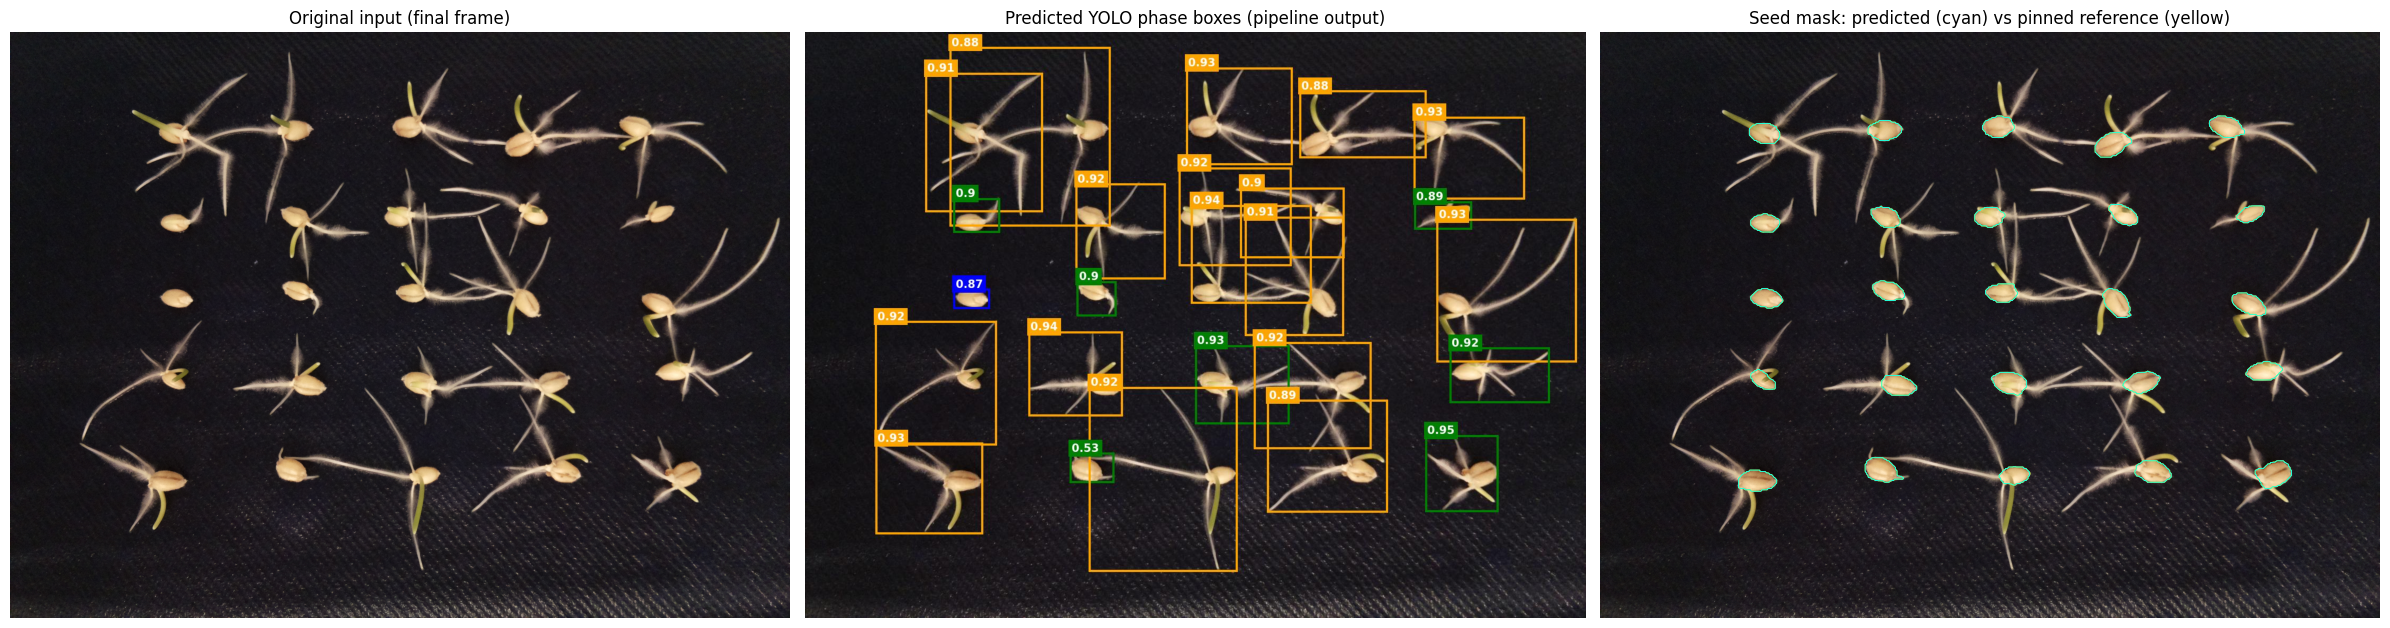

In [ ]:
import matplotlib.pyplot as plt
from skimage import io, measure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
img = io.imread("./example_G7/G7_20221029_2018.jpg")
axes[0].imshow(img); axes[0].set_title("Original input (final frame)"); axes[0].axis("off")
overlay = io.imread("./traits/phase/G7_20221029_2018.jpg")
axes[1].imshow(overlay); axes[1].set_title("Predicted YOLO phase boxes (pipeline output)"); axes[1].axis("off")
ref_mask = io.imread("/content/ref/model_predict__G7_seed__G7_20221029_2018.png") > 0
axes[2].imshow(img); axes[2].contour(ref_mask, colors="yellow", linewidths=0.6)
axes[2].contour(io.imread("./model_predict/G7_seed/G7_20221029_2018.png") > 0, colors="cyan", linewidths=0.6)
axes[2].set_title("Seed mask: predicted (cyan) vs pinned reference (yellow)"); axes[2].axis("off")
plt.tight_layout(); plt.savefig("/content/fig_overlay.png", dpi=110, bbox_inches="tight"); plt.show()

**Radicle growth profile** (this notebook's central result): cumulative radicle length per seed
over the 16-frame time series, converted to mm with the authors' calibration. Plot generated for
this notebook from the pipeline's own output (not an author figure).


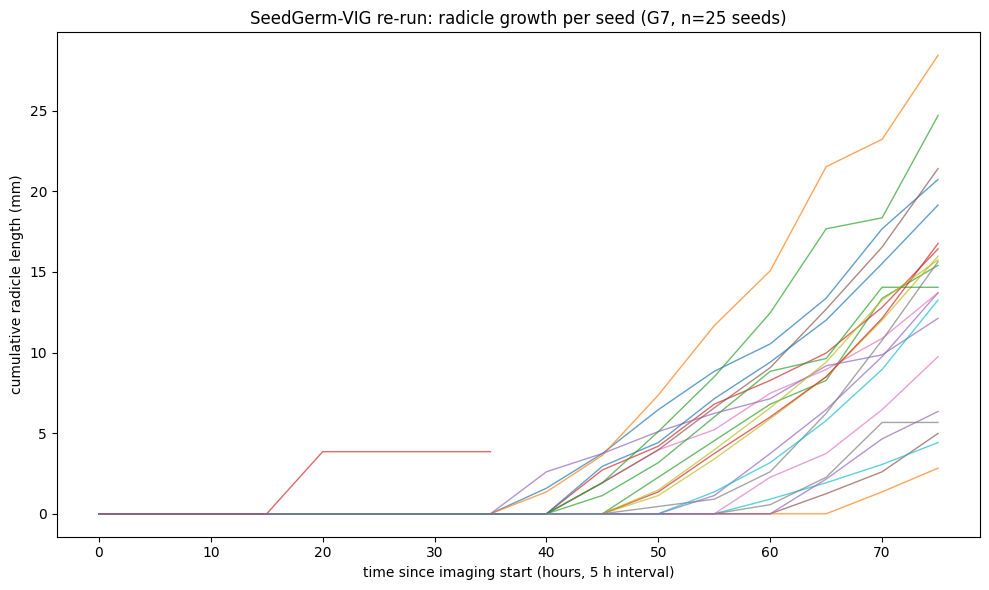

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("./traits/traits/radicle_length.csv", index_col=0)
hours = np.arange(df.shape[1]) * 5
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(df.shape[0]):
    ax.plot(hours[: len(df.iloc[i].dropna())], df.iloc[i].dropna().values, lw=1, alpha=0.7)
ax.set_xlabel("time since imaging start (hours, 5 h interval)")
ax.set_ylabel("cumulative radicle length (mm)")
ax.set_title("SeedGerm-VIG re-run: radicle growth per seed (G7, n=%d seeds)" % df.shape[0])
plt.tight_layout(); plt.savefig("/content/fig_radicle.png", dpi=110); plt.show()

**Root-tip tracking overlay** (author pipeline figure, final frame): skeleton (white), seed
contours (red), tracked root tips (colored points).


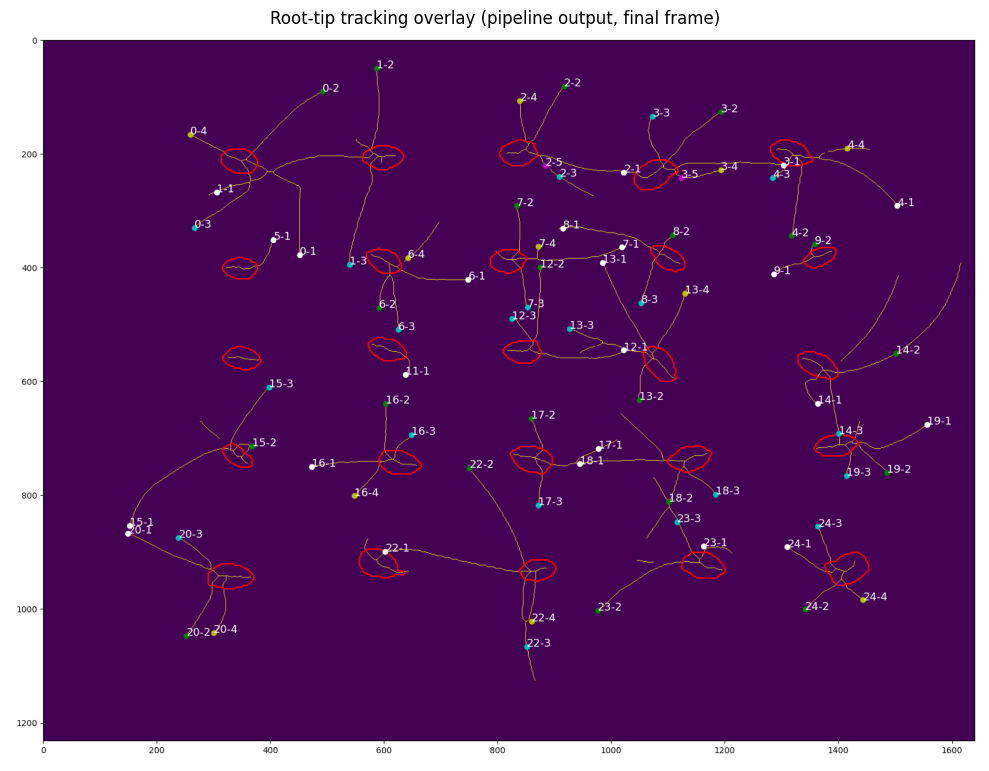

In [ ]:
from skimage import io
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(io.imread("./traits/traits/root_mask2/fig_15_G7_20221029_2018.png"))
ax.axis("off"); ax.set_title("Root-tip tracking overlay (pipeline output, final frame)")
plt.tight_layout(); plt.savefig("/content/fig_tracking.png", dpi=110, bbox_inches="tight"); plt.show()

## Timing and environment record


In [ ]:
total_min = (time.time() - T0) / 60
print("Stage timings (s since notebook start):")
for name, t in STAGES:
    print(f"  {name:38s} {t:8.0f}")
print(f"TOTAL: {total_min:.1f} min")
try:
    import torch
    print("torch", torch.__version__, "| CUDA avail:", torch.cuda.is_available())
except Exception:
    pass

Stage timings (s since notebook start):
  weights downloaded+extracted                 25
  example images verified                      34
  step1 U-Net masks                            71
  step2.1 YOLO phase detection                 86
  step2.2 phase correction loop               472
  step3 root tracking loop                   1638
  verification                               1694
TOTAL: 28.4 min
torch 2.11.0+cu130 | CUDA avail: True


## Interpretation, limitations, references

- **What was executed:** the authors' released SeedGerm-VIG pipeline (U-Net ×3, YOLOv8x-Germ,
  temporal phase correction, skeleton root tracking) on their exemplar G7 wheat series, with
  byte-verified inputs/weights and comparison against their pinned reference outputs.
- **What this does and does not show:** a single-genotype example run; it does not re-validate
  the paper's 21-wheat-genotype vigor matrix, ISTA comparison, or barley/rice extensions.
  Seedling-emergence/chloroplast-duration outputs and secondary-root analysis depth were omitted
  from this demo (pipeline code retained them; see omission note in the run report).
- **Adaptations** (all marked `# ADAPTATION`): current Colab frameworks (TF/torch/ultralytics)
  instead of the pinned 2020-era stack; `os.mkdirs` → `os.makedirs` bug fix; three identical
  Step_1 loops wrapped into one parameterized function; Keras/SavedModel dual loader.
- **License:** author code/notebooks/models MIT; image series CC0 (BioImage Archive S-BIAD1852).
- **Primary sources:** GigaScience 2025;14:giaf129 (PMC12648739); `The-Zhou-Lab/SeedGerm-VIG`
  tag v1.12 (commit `cd86a6f0c81e`); release assets `DL_models_for_wheat.zip`,
  `SeedGerm-VIG_jupyter_notebooks.zip`. PhenoPaper investigation
  `p-5cde365672db8ac0d0a4a5592fc30d2e-20260930T124757Z-3668176` was used as prior research
  guidance only; all parameters were re-verified against the pinned author code.

**日本語まとめ:** 本ノートブックは著者公開コードをほぼそのまま実行し、G7 例(25 粒)で
U-Net セグメンテーション→YOLO 発芽段階検出→時間補正→根端追跡を再現しました。出力は
著者ピン留めの参照 CSV/マスクと比較されています。単一遺伝子型の最小例であり、論文の
全遺伝子型評価・ISTA 比較は含みません。実行環境は現行 Colab(T4 GPU)で、2020 年当時の
バージョン固定からの最小限の適応は `# ADAPTATION` として明示しています。
